# Questão da Função


Aproximação de função com MLP usando scikit-learn (MLPRegressor).


In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

In [ ]:
def f(x):
    return 10 * x**5 + 5 * x**4 + 2 * x**3 - 0.5 * x**2 + 3 * x + 2

N_AMOSTRAS = 400
X_TODOS = np.random.uniform(0, 5, N_AMOSTRAS)
Y_TODOS = f(X_TODOS)

X_treino, X_teste, y_treino, y_teste = train_test_split(X_TODOS, Y_TODOS, test_size=0.2, random_state=42)

X_treino = X_treino.reshape(-1, 1)
X_teste = X_teste.reshape(-1, 1)

print(f"Treino: {len(X_treino)} | Teste: {len(X_teste)}")

Treino: 320 | Teste: 80


f(x) varia de 2 até 34630, portanto é preciso normalizar para que eles estejam em uma escala menor.

In [ ]:
# Normalização (fit SÓ no treino)
scaler_x = StandardScaler().fit(X_treino)
scaler_y = StandardScaler().fit(y_treino.reshape(-1, 1))

Xn_treino = scaler_x.transform(X_treino)
Xn_teste = scaler_x.transform(X_teste)
yn_treino = scaler_y.transform(y_treino.reshape(-1, 1)).ravel()
yn_teste = scaler_y.transform(y_teste.reshape(-1, 1)).ravel()

Arquitetura implementada com três camadas ocultas, com 64, 64 e 32 neurônios, ativação Relu e otimizador Adam, alem do learning rate adaptive para reduziro o passo quando o treino estagnar.

In [ ]:
rede = MLPRegressor(
    hidden_layer_sizes=(64, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    learning_rate="adaptive",
    random_state=42,
)

EPOCAS = 1000
hist_erro_treino, hist_erro_teste = [], []
melhor_erro_teste = np.inf
melhor_rede = None

for epoca in range(EPOCAS):
    rede.partial_fit(Xn_treino, yn_treino)

    pred_treino = rede.predict(Xn_treino)
    pred_teste = rede.predict(Xn_teste)

    erro_treino = mean_squared_error(yn_treino, pred_treino)
    erro_teste = mean_squared_error(yn_teste, pred_teste)

    hist_erro_treino.append(erro_treino)
    hist_erro_teste.append(erro_teste)

    # Checkpoint escolhido pelo Teste
    if erro_teste < melhor_erro_teste:
        melhor_erro_teste = erro_teste
        melhor_rede = copy.deepcopy(rede)

    if epoca % 100 == 0 or epoca == EPOCAS - 1:
        print(f"Época {epoca:5d} | MSE treino: {erro_treino:.6f} | MSE teste: {erro_teste:.6f}")

rede = melhor_rede
print(f"\nMelhor MSE de Teste (normalizado): {melhor_erro_teste:.6f}")

Época     0 | MSE treino: 0.895283 | MSE teste: 0.734693
Época   100 | MSE treino: 0.000853 | MSE teste: 0.000757
Época   200 | MSE treino: 0.000012 | MSE teste: 0.000016
Época   300 | MSE treino: 0.000004 | MSE teste: 0.000006
Época   400 | MSE treino: 0.000003 | MSE teste: 0.000004
Época   500 | MSE treino: 0.000003 | MSE teste: 0.000004
Época   600 | MSE treino: 0.000002 | MSE teste: 0.000003
Época   700 | MSE treino: 0.000008 | MSE teste: 0.000010
Época   800 | MSE treino: 0.000003 | MSE teste: 0.000005
Época   900 | MSE treino: 0.000002 | MSE teste: 0.000003
Época   999 | MSE treino: 0.000002 | MSE teste: 0.000003

Melhor MSE de Teste (normalizado): 0.000003


O modelo escolhido para avaliação do conjunto de teste foi o que teve o menor erro quadrático.

In [ ]:
pred_teste_norm = rede.predict(Xn_teste)
pred_teste = scaler_y.inverse_transform(pred_teste_norm.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_teste, pred_teste)
mse = mean_squared_error(y_teste, pred_teste)
rmse = np.sqrt(mse)

print("===== Métricas no conjunto de TESTE (escala original) =====")
print(f"MAE  : {mae:,.4f}")
print(f"MSE  : {mse:,.4f}")
print(f"RMSE : {rmse:,.4f}")

===== Métricas no conjunto de TESTE (escala original) =====
MAE  : 8.9903
MSE  : 208.0024
RMSE : 14.4223


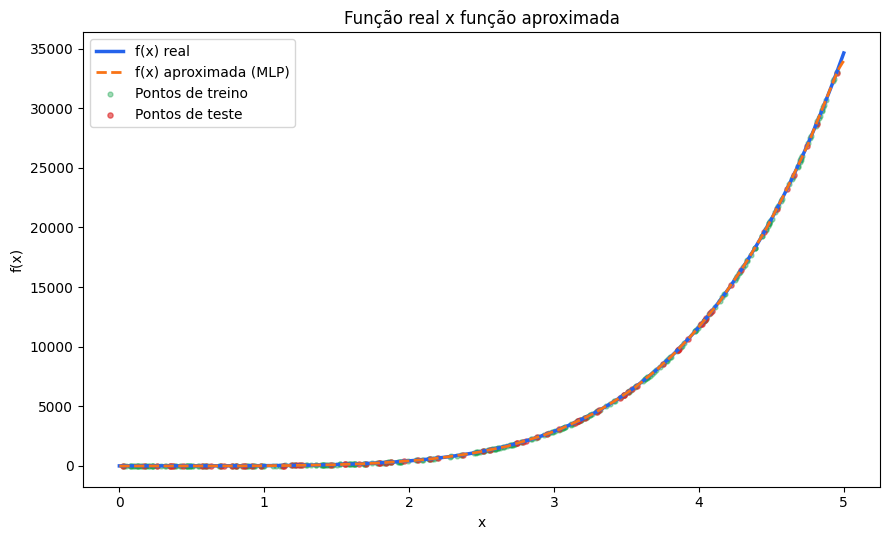

In [ ]:
# Funçao real x aproximada

x_denso = np.linspace(0, 5, 500)
y_denso_real = f(x_denso)
x_denso_norm = scaler_x.transform(x_denso.reshape(-1, 1))
y_denso_pred = scaler_y.inverse_transform(rede.predict(x_denso_norm).reshape(-1, 1)).ravel()

plt.figure(figsize=(9, 5.5))
plt.plot(x_denso, y_denso_real, label="f(x) real", color="#2563eb", linewidth=2.5)
plt.plot(x_denso, y_denso_pred, label="f(x) aproximada (MLP)", color="#f97316", linewidth=2, linestyle="--")
plt.scatter(X_treino, y_treino, s=12, color="#16a34a", alpha=0.4, label="Pontos de treino")
plt.scatter(X_teste, y_teste, s=14, color="#dc2626", alpha=0.6, label="Pontos de teste")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Função real x função aproximada")
plt.legend()
plt.tight_layout()
plt.show()

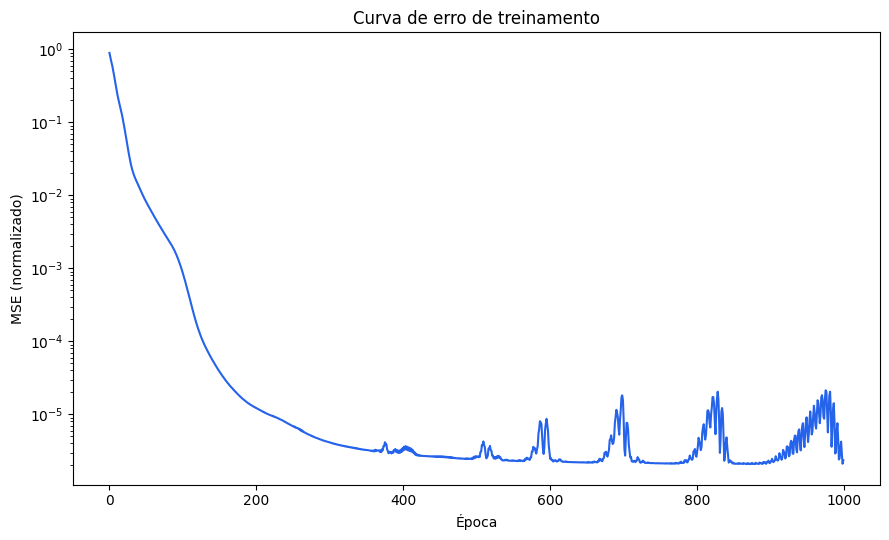

In [ ]:
#  Curva de erro (treino)

plt.figure(figsize=(9, 5.5))
plt.plot(hist_erro_treino, color="#2563eb")
plt.xlabel("Época")
plt.ylabel("MSE (normalizado)")
plt.yscale("log")
plt.title("Curva de erro de treinamento")
plt.tight_layout()
plt.show()

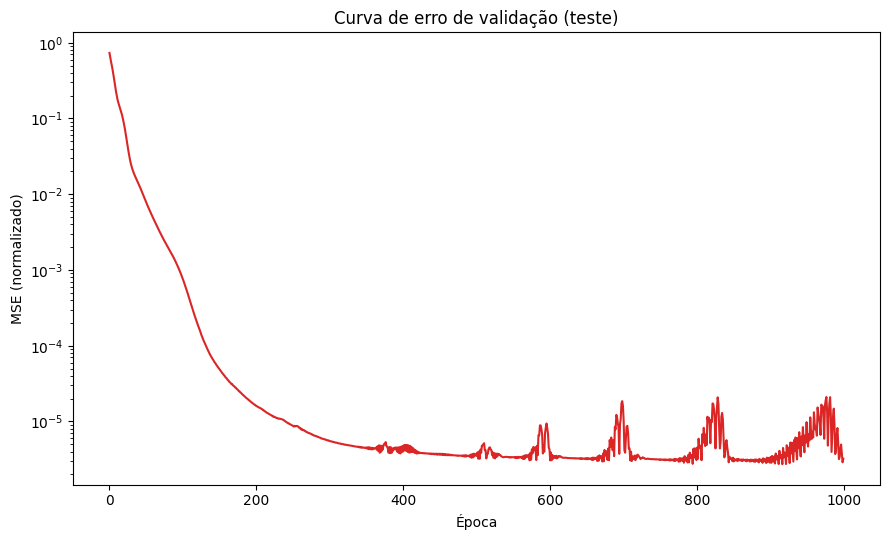

In [ ]:
# Curva de erro de validação (teste)

plt.figure(figsize=(9, 5.5))
plt.plot(hist_erro_teste, color="#dc2626")
plt.xlabel("Época")
plt.ylabel("MSE (normalizado)")
plt.yscale("log")
plt.title("Curva de erro de validação (teste)")
plt.tight_layout()
plt.show()

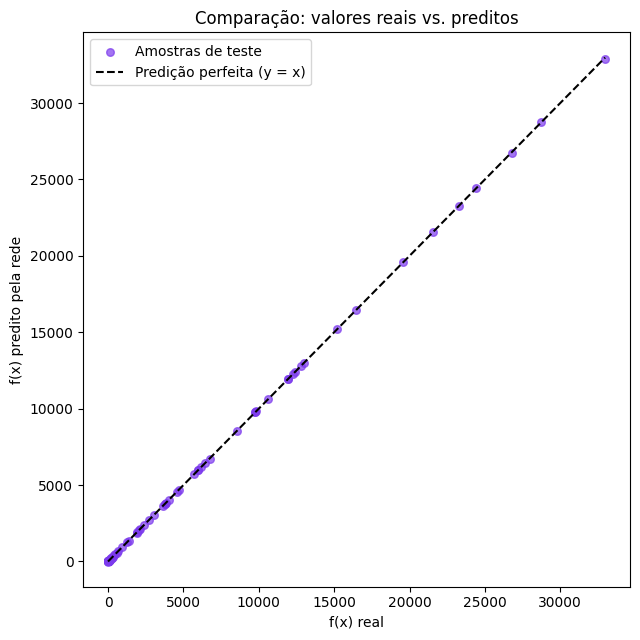

In [ ]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_teste, pred_teste, color="#7c3aed", alpha=0.7, s=30, label="Amostras de teste")
lim_min, lim_max = min(y_teste.min(), pred_teste.min()), max(y_teste.max(), pred_teste.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--", linewidth=1.5, label="Predição perfeita (y = x)")
plt.xlabel("f(x) real")
plt.ylabel("f(x) predito pela rede")
plt.title("Comparação: valores reais vs. preditos")
plt.legend()
plt.tight_layout()
plt.show()

# Questão 1b)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)

In [ ]:
dados = fetch_california_housing(as_frame=True)
df_california = dados.frame

In [ ]:
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df_california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Análise de Nulos

In [ ]:
df_null = df_california.isna().sum()
sum(df_null)

0

Matriz de Correlação entre os atributos

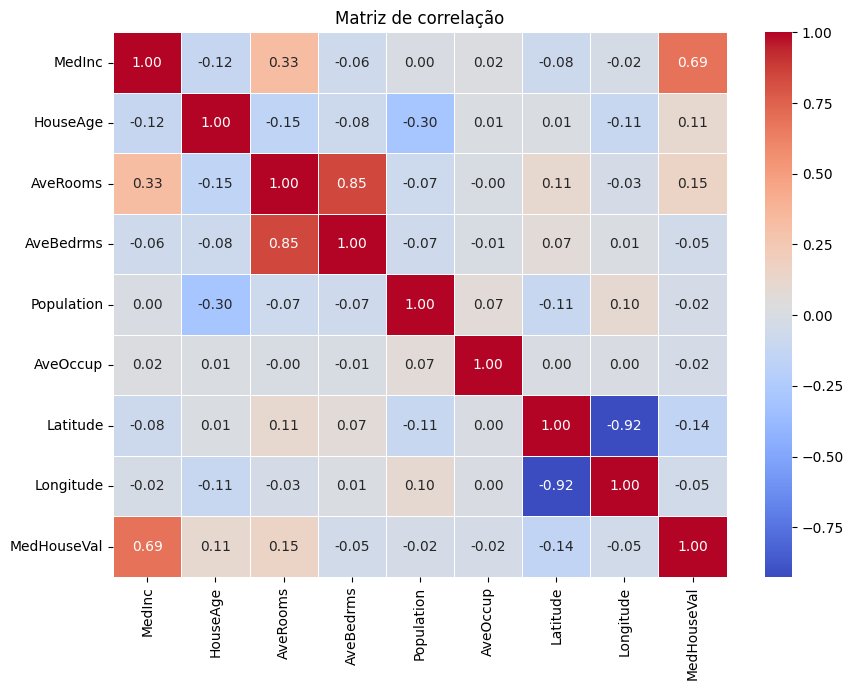

In [ ]:
plt.figure(figsize=(9, 7))
corr = df_california.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlação")
plt.tight_layout()
plt.show()

Divisão em Treino e Teste

In [ ]:
X = df_california.drop(columns="MedHouseVal").values
y = df_california["MedHouseVal"].values

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {len(X_treino)} | Teste: {len(X_teste)}")

Treino: 16512 | Teste: 4128


Normalização

In [ ]:
scaler_x = StandardScaler().fit(X_treino)
scaler_y = StandardScaler().fit(y_treino.reshape(-1, 1))

Xn_treino = scaler_x.transform(X_treino)
Xn_teste = scaler_x.transform(X_teste)
yn_treino = scaler_y.transform(y_treino.reshape(-1, 1)).ravel()

In [ ]:
rede = MLPRegressor(
    hidden_layer_sizes=(64, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    learning_rate="adaptive",
    early_stopping=True,
    validation_fraction=0.2,   # 20% do TREINO vira validação interna
    n_iter_no_change=15,
    max_iter=1000,
    random_state=42,
)

rede.fit(Xn_treino, yn_treino)

print(f"Treino parou na época: {rede.n_iter_}")
print(f"Melhor score de validação (R²): {rede.best_validation_score_:.4f}")

Treino parou na época: 61
Melhor score de validação (R²): 0.7896


Gráfico da Curva de Erro

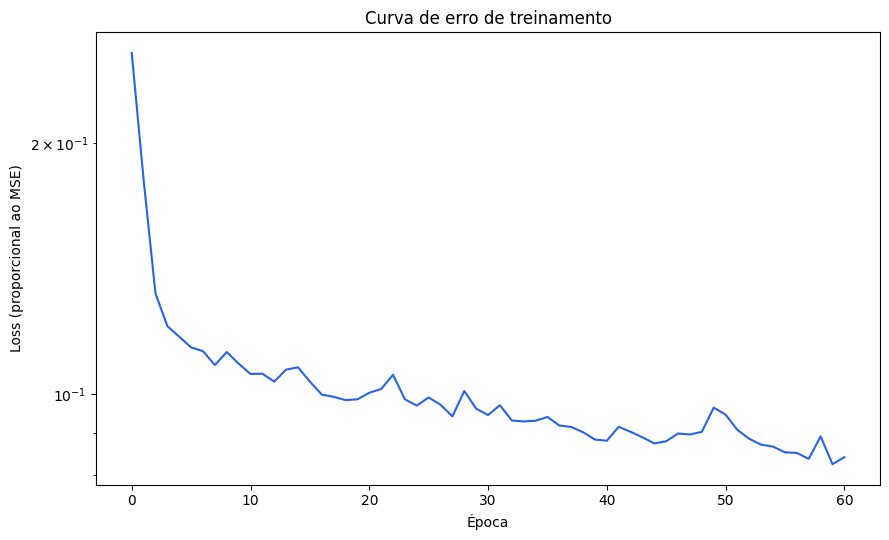

In [ ]:
plt.figure(figsize=(9, 5.5))
plt.plot(rede.loss_curve_, color="#2563eb")
plt.xlabel("Época")
plt.ylabel("Loss (proporcional ao MSE)")
plt.yscale("log")
plt.title("Curva de erro de treinamento")
plt.tight_layout()
plt.show()

Curva de Validação

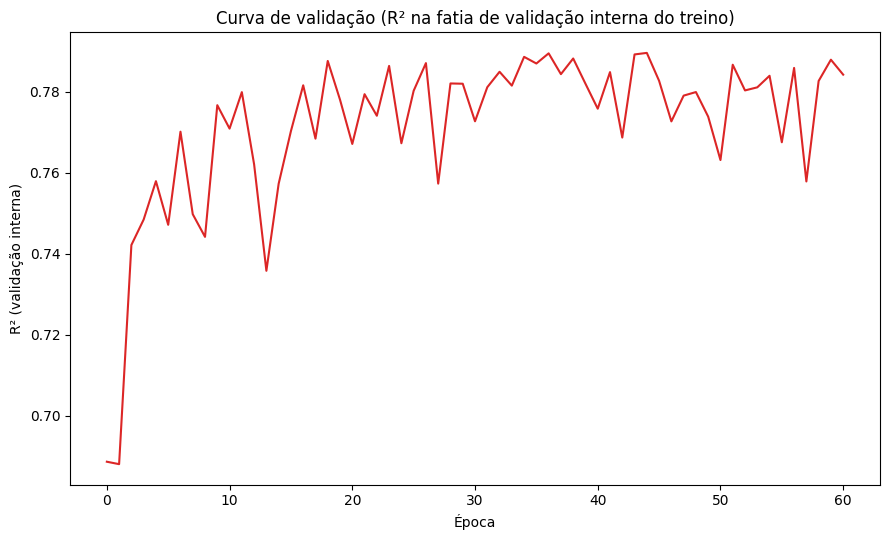

In [ ]:
# O MLPRegressor expõe a validação interna como score R² por época
# (mais alto = melhor), não como erro — por isso o eixo aqui é diferente
# da curva de treinamento (que é loss, mais baixo = melhor).
plt.figure(figsize=(9, 5.5))
plt.plot(rede.validation_scores_, color="#dc2626")
plt.xlabel("Época")
plt.ylabel("R² (validação interna)")
plt.title("Curva de validação (R² na fatia de validação interna do treino)")
plt.tight_layout()
plt.show()

Métricas

In [ ]:
pred_teste_norm = rede.predict(Xn_teste)
pred_teste = scaler_y.inverse_transform(pred_teste_norm.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_teste, pred_teste)
mse = mean_squared_error(y_teste, pred_teste)
rmse = np.sqrt(mse)

print("===== Métricas no conjunto de TESTE (escala original, US$ 100.000) =====")
print(f"MAE  : {mae:.4f}  (~US$ {mae*100000:,.0f})")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}  (~US$ {rmse*100000:,.0f})")

===== Métricas no conjunto de TESTE (escala original, US$ 100.000) =====
MAE  : 0.3615  (~US$ 36,145)
MSE  : 0.2723
RMSE : 0.5218  (~US$ 52,179)


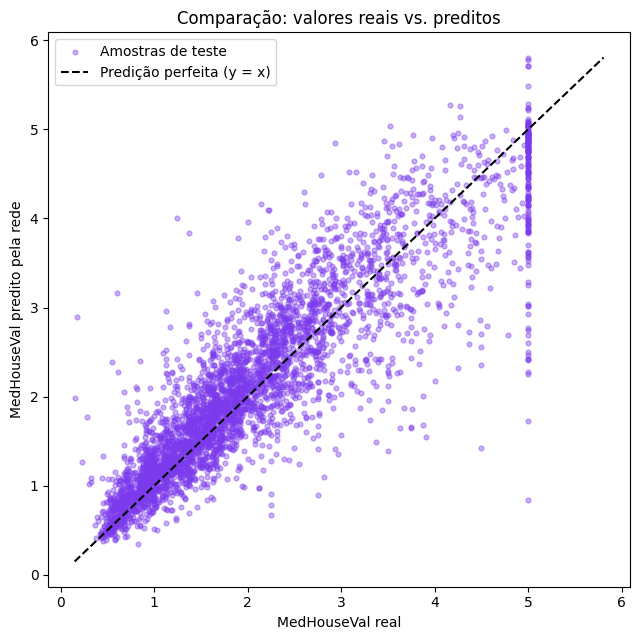

In [ ]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_teste, pred_teste, color="#7c3aed", alpha=0.4, s=12, label="Amostras de teste")
lim_min, lim_max = min(y_teste.min(), pred_teste.min()), max(y_teste.max(), pred_teste.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color="black", linestyle="--",
          linewidth=1.5, label="Predição perfeita (y = x)")
plt.xlabel("MedHouseVal real")
plt.ylabel("MedHouseVal predito pela rede")
plt.title("Comparação: valores reais vs. preditos")
plt.legend()
plt.tight_layout()
plt.show()

Na base de dados, todos os imóveis que eram mais caros do que 500.000 foram colocados como 500.000, por isso essa linha vertical na direita do gráfico.

In [ ]:
df_california[df_california['MedHouseVal'] > 4.9]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
89,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27,5.00001
459,1.1696,52.0,2.436000,0.944000,1349.0,5.396000,37.87,-122.25,5.00001
493,7.8521,52.0,7.794393,1.051402,517.0,2.415888,37.86,-122.24,5.00001
494,9.3959,52.0,7.512097,0.955645,1366.0,2.754032,37.85,-122.24,5.00001
509,7.8772,52.0,8.282548,1.049861,947.0,2.623269,37.83,-122.23,5.00001
...,...,...,...,...,...,...,...,...,...
20422,5.1457,35.0,6.958333,1.217593,576.0,2.666667,34.14,-118.90,5.00001
20426,10.0472,11.0,9.890756,1.159664,415.0,3.487395,34.18,-118.69,5.00001
20427,8.6499,4.0,7.236059,1.032528,5495.0,2.553439,34.19,-118.80,5.00001
20436,12.5420,10.0,9.873315,1.102426,1179.0,3.177898,34.21,-118.69,5.00001


# Questão Titanic

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [ ]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# Tratamento dos Dados

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# O atributo 'Cabin' tem muitos valores nulos, então optei por remover a coluna, visto que não tem como inputar de algum jeito.
# O atributo 'Name', 'PassengerId' e 'Ticket 'não agregam em nada para a predição, pois nenhum deles pode ter influenciado na morte.


train = train.drop(columns=['Cabin', 'Name', 'PassengerId', 'Ticket'])

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


Análise de valores nulos

In [ ]:
train_null = train.isna().sum()
sum(train_null)

179

Análise de Duplicatas

In [ ]:
dup = train.duplicated()
sum(dup)

111

In [ ]:
train = train.drop_duplicates()

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  780 non-null    int64  
 1   Pclass    780 non-null    int64  
 2   Sex       780 non-null    object 
 3   Age       676 non-null    float64
 4   SibSp     780 non-null    int64  
 5   Parch     780 non-null    int64  
 6   Fare      780 non-null    float64
 7   Embarked  778 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 54.8+ KB


Analisando o balanceamento da classe alvo

In [ ]:
train['Survived'].value_counts() # Balanceado

,count
Survived,
0,458
1,322


Caso houvesse um desbalanceamento mais considerável, poderia ser feito técnicas de balanceamento como Undersampling e Oversampling.

In [ ]:
labelencoder_y = LabelEncoder()
train['Sex'] = labelencoder_y.fit_transform(train['Sex'])
train['Embarked'] = labelencoder_y.fit_transform(train['Embarked'])

LabelEncoding para transformar as colunas categóricas em numéricas.

In [ ]:
train

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,1
887,1,1,0,19.0,0,0,30.0000,2
888,0,3,0,NaN,1,2,23.4500,2
889,1,1,1,26.0,0,0,30.0000,0


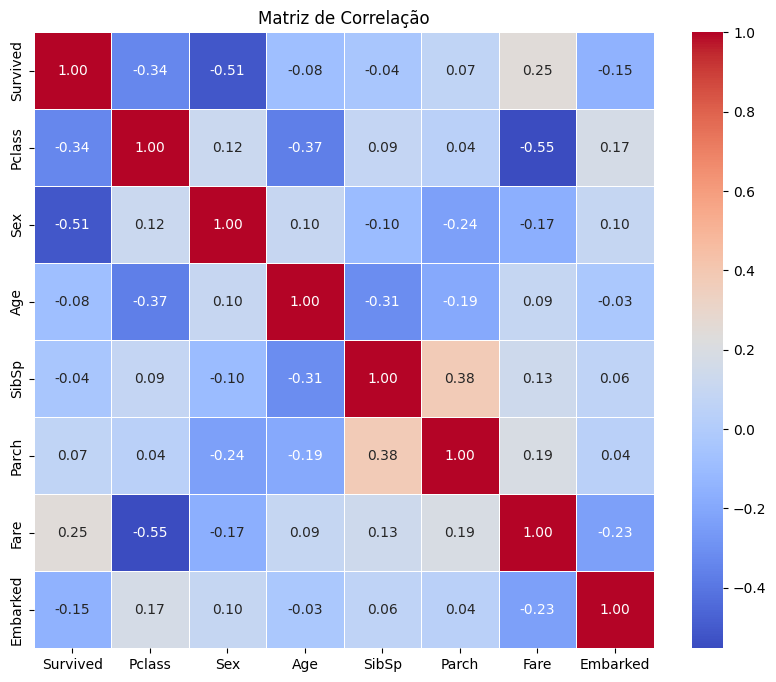

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcula a matriz de correlação
corr = train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

 A Pclass e a o sexo tem uma alta correlação com o atributo 'Survived'


# Separando em Treino e Teste

In [ ]:
x = train.drop(columns = 'Survived')
y = train['Survived']

In [ ]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=45, test_size=0.2)

In [ ]:
xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 624 entries, 545 to 456
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    624 non-null    int64  
 1   Sex       624 non-null    int64  
 2   Age       538 non-null    float64
 3   SibSp     624 non-null    int64  
 4   Parch     624 non-null    int64  
 5   Fare      624 non-null    float64
 6   Embarked  624 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 39.0 KB


In [ ]:
xtest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 451 to 712
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    156 non-null    int64  
 1   Sex       156 non-null    int64  
 2   Age       138 non-null    float64
 3   SibSp     156 non-null    int64  
 4   Parch     156 non-null    int64  
 5   Fare      156 non-null    float64
 6   Embarked  156 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 9.8 KB


Ainda possuem valores nulos na coluna de idade. Optei por preencher esses valores com a média das idades APÓS a separação entre treino e teste para não haver vazamento de dados.

In [ ]:
xtrain['Age'] = xtrain['Age'].fillna(xtrain['Age'].mean())
xtest['Age'] = xtest['Age'].fillna(xtest['Age'].mean())

In [ ]:
xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 624 entries, 545 to 456
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    624 non-null    int64  
 1   Sex       624 non-null    int64  
 2   Age       624 non-null    float64
 3   SibSp     624 non-null    int64  
 4   Parch     624 non-null    int64  
 5   Fare      624 non-null    float64
 6   Embarked  624 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 39.0 KB


In [ ]:
xtest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 451 to 712
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    156 non-null    int64  
 1   Sex       156 non-null    int64  
 2   Age       156 non-null    float64
 3   SibSp     156 non-null    int64  
 4   Parch     156 non-null    int64  
 5   Fare      156 non-null    float64
 6   Embarked  156 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 9.8 KB


In [ ]:
train.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,780.000000,780.000000,780.000000,676.000000,780.000000,780.000000,780.000000,780.000000
mean,0.412821,2.246154,0.625641,29.812751,0.525641,0.417949,34.829108,1.530769
std,0.492657,0.854452,0.484267,14.727098,0.988046,0.838536,52.263440,0.807746
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,20.000000,0.000000,0.000000,8.050000,1.000000
50%,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,15.950000,2.000000
75%,1.000000,3.000000,1.000000,39.000000,1.000000,1.000000,34.375000,2.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,3.000000


Os atributos do dataset possuem escalas muito diferentes, portanto é preciso normalizar os dados para uma mesma escala.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
xtrain[xtrain.columns] = scaler.fit_transform(xtrain[xtrain.columns])
xtest[xtest.columns] = scaler.transform(xtest[xtest.columns]) # Fit apenas no treinamento

In [ ]:
xtrain

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
545,0.0,1.0,0.798944,0.000,0.000000,0.050749,0.666667
840,1.0,1.0,0.246042,0.000,0.000000,0.015469,0.666667
618,0.5,0.0,0.044986,0.250,0.166667,0.076123,0.666667
246,1.0,0.0,0.308872,0.000,0.000000,0.015176,0.666667
337,0.0,0.0,0.509927,0.000,0.000000,0.262527,0.000000
...,...,...,...,...,...,...,...
824,1.0,1.0,0.019854,0.500,0.166667,0.077465,0.666667
688,1.0,1.0,0.220910,0.000,0.000000,0.015216,0.666667
615,0.5,0.0,0.296306,0.125,0.333333,0.126872,0.666667
727,1.0,0.0,0.370212,0.000,0.000000,0.015103,0.333333


# Treinamento

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score,
                              recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# Garantindo que os conjuntos estejam em float que é o formato que o keras espera
xtrain = np.asarray(xtrain).astype('float32')
xtest  = np.asarray(xtest).astype('float32')
ytrain = np.asarray(ytrain).astype('float32')
ytest  = np.asarray(ytest).astype('float32')

Arquitetura

In [ ]:
n_features = xtrain.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(32, activation='relu', name='oculta_1'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu', name='oculta_2'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid', name='saida')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    xtrain, ytrain,
    validation_split=0.2,   # separa 20% do TREINO para validação (não usa o teste)
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5251 - loss: 0.6954 - val_accuracy: 0.6400 - val_loss: 0.6642
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5952 - loss: 0.6616 - val_accuracy: 0.6480 - val_loss: 0.6403
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5852 - loss: 0.6604 - val_accuracy: 0.6720 - val_loss: 0.6233
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6333 - loss: 0.6384 - val_accuracy: 0.6880 - val_loss: 0.6079
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6453 - loss: 0.6318 - val_accuracy: 0.7040 - val_loss: 0.5921
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7054 - loss: 0.6165 - val_accuracy: 0.7360 - val_loss: 0.5747
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6693 - loss: 0.6133 - val_accuracy: 0.8160 - val_loss: 0.5563
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6934 - loss: 0.5980 - val_accuracy: 0.8240 - 

Curva de Erro

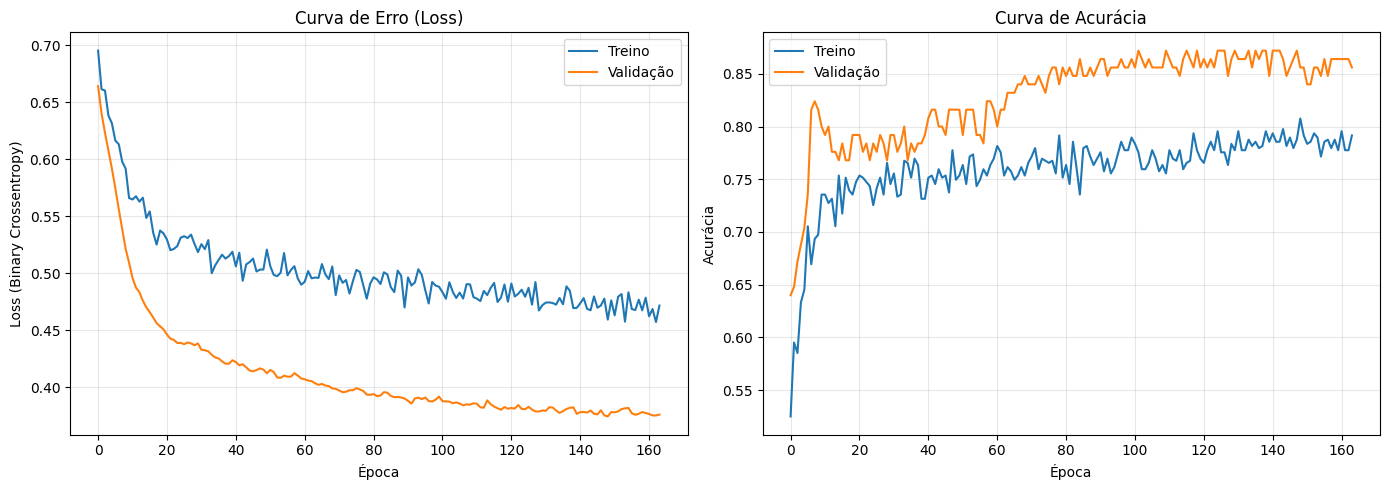

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('Curva de Erro (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Treino')
axes[1].plot(history.history['val_accuracy'], label='Validação')
axes[1].set_title('Curva de Acurácia')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
y_pred_proba = model.predict(xtest)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


Matriz de Confusão

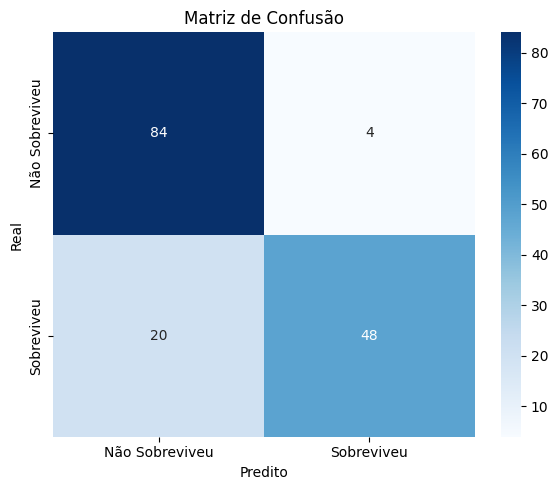

In [ ]:
cm = confusion_matrix(ytest, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Sobreviveu', 'Sobreviveu'],
            yticklabels=['Não Sobreviveu', 'Sobreviveu'])
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

Métricas

In [ ]:
acc = accuracy_score(ytest, y_pred)
prec = precision_score(ytest, y_pred)
rec = recall_score(ytest, y_pred)
f1 = f1_score(ytest, y_pred)

print("\n===== MÉTRICAS NO CONJUNTO DE TESTE =====")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nRelatório completo:")
print(classification_report(ytest, y_pred,
                             target_names=['Não Sobreviveu', 'Sobreviveu']))


===== MÉTRICAS NO CONJUNTO DE TESTE =====
Accuracy:  0.8462
Precision: 0.9231
Recall:    0.7059
F1-score:  0.8000

Relatório completo:
                precision    recall  f1-score   support

Não Sobreviveu       0.81      0.95      0.88        88
    Sobreviveu       0.92      0.71      0.80        68

      accuracy                           0.85       156
     macro avg       0.87      0.83      0.84       156
  weighted avg       0.86      0.85      0.84       156



# Questão 3 - Fashion-MNIST

Este notebook está dividido em seções que respondem às Questões 3 e 4:

- **Seção 1** — Carregamento e preparação da base Fashion-MNIST
- **Seção 2 (Questão 3a)** — Rede Perceptron de Múltiplas Camadas (MLP)
- **Seção 3 (Questão 3b)** — Rede Neural Convolucional (CNN)
- **Seção 4** — Comparação final entre MLP e CNN
- **Seção 5 (Questão 4a)** — Visualização dos filtros da primeira camada convolucional
- **Seção 6 (Questão 4b)** — Mapas de ativação de uma camada convolucional intermediária



## 0. Imports e configurações gerais

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.optimizers import Adam


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('whitegrid')
print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1. Carregamento e preparação da base Fashion-MNIST

- 60.000 imagens de treino + 10.000 de teste, 28x28 pixels, escala de cinza, 10 classes.
- Separamos 10% do treino para validação (usada nas curvas de erro/acurácia).
- Normalizamos os pixels para o intervalo [0, 1].


In [ ]:
import matplotlib.pyplot as plt
from tensorflow import keras

# Carrega o dataset
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Nome das classes
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Verifica as dimensões dos conjuntos
print("Treino:", x_train_full.shape, y_train_full.shape)
print("Teste :", x_test.shape, y_test.shape)

# Verifica os labels existentes
print("\nLabels existentes:", sorted(set(y_train_full)))

# Mostra o mapeamento dos labels
print("\nMapeamento das classes:")
for i, nome in enumerate(class_names):
    print(f"{i}: {nome}")


Treino: (60000, 28, 28) (60000,)
Teste : (10000, 28, 28) (10000,)

Labels existentes: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]

Mapeamento das classes:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


### Normalização dos dados

Os valores dos pixels foram normalizados para o intervalo **[0, 1]** dividindo-os por **255**, pois as imagens originais possuem intensidades entre **0 e 255**. Essa etapa melhora a estabilidade numérica e acelera a convergência do treinamento da rede neural, além de ser uma prática recomendada para modelos baseados em gradiente.

In [ ]:
# Normalização
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Split treino / validação (estratificado)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.1, random_state=SEED, stratify=y_train_full
)

print("Treino :", x_train.shape, y_train.shape)
print("Validação:", x_val.shape, y_val.shape)
print("Teste  :", x_test.shape, y_test.shape)


Treino : (54000, 28, 28) (54000,)
Validação: (6000, 28, 28) (6000,)
Teste  : (10000, 28, 28) (10000,)


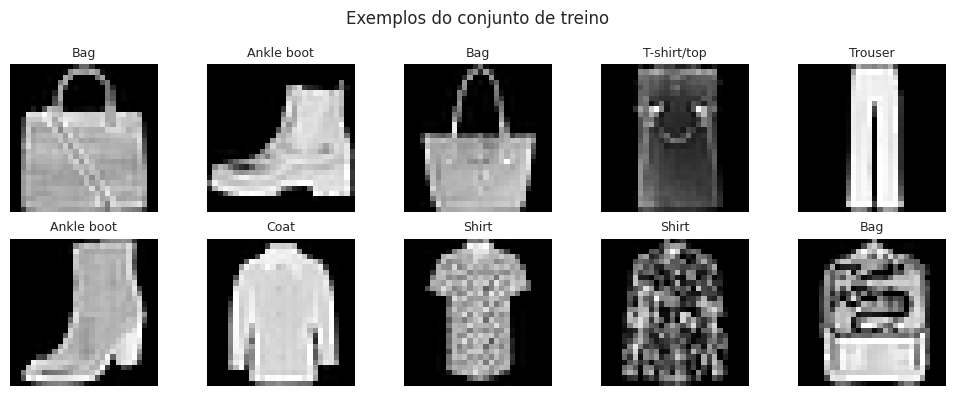

In [ ]:
# Visualização de algumas amostras
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Exemplos do conjunto de treino')
plt.tight_layout()
plt.show()


## a) Rede Perceptron de Múltiplas Camadas (MLP)

### Arquitetura utilizada

| Camada | Tipo | Saída | Ativação |
|---|---|---|---|
| Entrada | Flatten | 784 | - |
| Oculta 1 | Dense | 256 | ReLU |
| Dropout | Dropout(0.3) | 256 | - |
| Oculta 2 | Dense | 128 | ReLU |
| Dropout | Dropout(0.3) | 128 | - |
| Saída | Dense | 10 | Softmax |

Otimizador: Adam · Função de perda: Sparse Categorical Crossentropy


### Justificativa da arquitetura

A arquitetura MLP foi definida com duas camadas densas (256 e 128 neurônios) para permitir que o modelo aprenda representações não lineares dos dados sem se tornar excessivamente complexo para o Fashion MNIST. A função de ativação **ReLU** foi utilizada por sua eficiência computacional e por reduzir problemas de gradientes pequenos durante o treinamento. As camadas de **Dropout (0,4)** ajudam a minimizar o sobreajuste, enquanto a camada de saída com **Softmax** produz as probabilidades das 10 classes do problema de classificação multiclasse.

### Justificativa do pré-processamento

As imagens do Fashion MNIST possuem dimensão **28 × 28 pixels**, enquanto uma MLP recebe como entrada um vetor unidimensional. Assim, cada imagem é transformada em um vetor de **784 atributos (28 × 28)** por meio da operação de *flatten*, preservando os valores dos pixels e tornando os dados compatíveis com as camadas densas da rede.

In [ ]:
# As imagens precisam ser "achatadas" (flatten) para entrar no MLP
x_train_mlp = x_train.reshape(-1, 784)
x_val_mlp   = x_val.reshape(-1, 784)
x_test_mlp  = x_test.reshape(-1, 784)

mlp = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='MLP')

mlp.summary()


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

### Justificativa da configuração de treinamento

O otimizador **Adam** foi escolhido por combinar boa velocidade de convergência e ajuste adaptativo da taxa de aprendizado. A função de perda **Sparse Categorical Crossentropy** é adequada para problemas de classificação multiclasse com rótulos inteiros, enquanto a métrica **accuracy** permite acompanhar o desempenho do modelo durante o treinamento e na validação ao longo das **20 épocas**, utilizando **lotes de 128 amostras** para equilibrar eficiência computacional e estabilidade na atualização dos pesos.

In [ ]:
mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mlp = mlp.fit(
    x_train_mlp, y_train,
    validation_data=(x_val_mlp, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7556 - loss: 0.6882 - val_accuracy: 0.8463 - val_loss: 0.4240
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8295 - loss: 0.4763 - val_accuracy: 0.8632 - val_loss: 0.3700
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8457 - loss: 0.4305 - val_accuracy: 0.8713 - val_loss: 0.3522
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8531 - loss: 0.4053 - val_accuracy: 0.8785 - val_loss: 0.3359
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8605 - loss: 0.3872 - val_accuracy: 0.8802 - val_loss: 0.3272
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8645 - loss: 0.3731 - val_accuracy: 0.8833 - val_loss: 0.3170
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8670 - loss: 0.3621 - val_accuracy: 0.8877 - val_loss: 0.3123
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8697 - loss: 0.3563 - val_accuracy: 

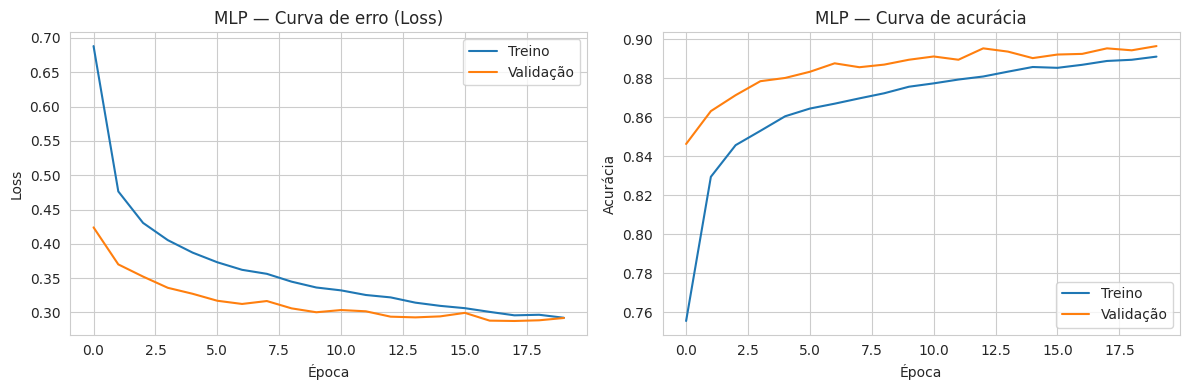

In [ ]:
def plot_history(history, title):
    """Plota curvas de erro (loss) e acurácia para treino e validação."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'], label='Treino')
    axes[0].plot(history.history['val_loss'], label='Validação')
    axes[0].set_title(f'{title} — Curva de erro (Loss)')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Treino')
    axes[1].plot(history.history['val_accuracy'], label='Validação')
    axes[1].set_title(f'{title} — Curva de acurácia')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Acurácia')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_mlp, 'MLP')


### Análise das curvas de treinamento

Observa-se que a **função de perda (loss)** diminui continuamente tanto no conjunto de treino quanto no de validação, indicando que o modelo está aprendendo de forma consistente. As curvas permanecem próximas durante todo o treinamento, sem aumento significativo da perda de validação, o que sugere ausência de sobreajuste (*overfitting*).

Em relação à **acurácia**, houve crescimento rápido nas primeiras épocas, seguido de estabilização em torno de **90%** para treino e validação. A pequena diferença entre as curvas demonstra boa capacidade de generalização do modelo, indicando que a arquitetura adotada e o uso de **Dropout** foram eficazes para reduzir o risco de sobreajuste.

Por fim, observa-se que após aproximadamente **12 a 15 épocas** os ganhos tornam-se marginais, sugerindo que o modelo já convergiu. Dessa forma, seria possível utilizar uma estratégia de **Early Stopping** para interromper o treinamento antecipadamente, reduzindo o tempo de treinamento sem perda significativa de desempenho.

>>> MLP — Acurácia final no conjunto de teste: 0.8759 (loss=0.3389)


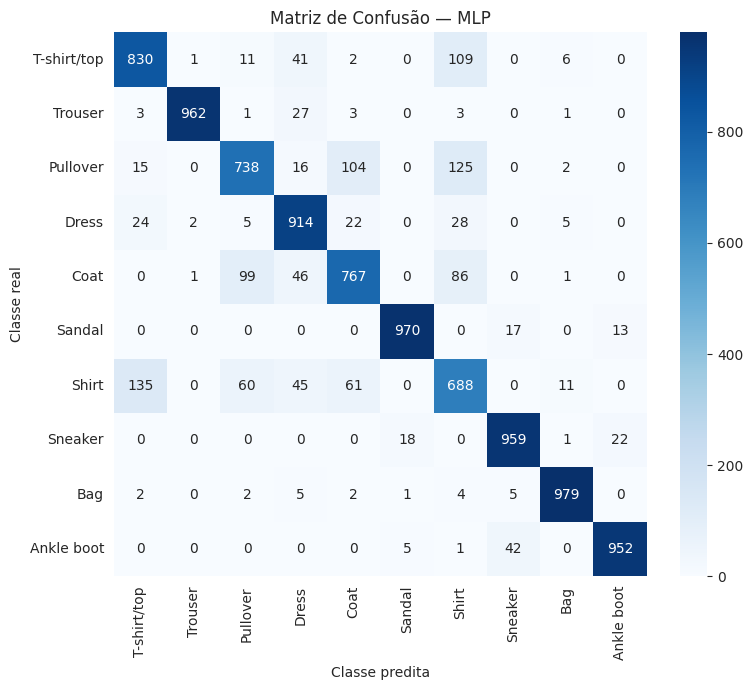

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.83      0.83      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.81      0.74      0.77      1000
       Dress       0.84      0.91      0.87      1000
        Coat       0.80      0.77      0.78      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.66      0.69      0.67      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.97      0.98      0.98      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [ ]:
def evaluate_model(model, x_eval, y_eval, class_names, title):
    """Avalia o modelo no conjunto de teste: acurácia, matriz de confusão e relatório."""
    test_loss, test_acc = model.evaluate(x_eval, y_eval, verbose=0)
    print(f'>>> {title} — Acurácia final no conjunto de teste: {test_acc:.4f} (loss={test_loss:.4f})')

    y_pred_probs = model.predict(x_eval, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusão — {title}')
    plt.xlabel('Classe predita'); plt.ylabel('Classe real')
    plt.tight_layout()
    plt.show()

    print(classification_report(y_eval, y_pred, target_names=class_names))
    return test_acc, y_pred

acc_mlp, y_pred_mlp = evaluate_model(mlp, x_test_mlp, y_test, class_names, 'MLP')


### Análise da matriz de confusão

A matriz de confusão mostra que a MLP obteve bom desempenho geral, com a maior parte das amostras corretamente classificadas, evidenciada pelos altos valores na diagonal principal. Classes como **Trouser (972)**, **Sandal (967)**, **Sneaker (969)**, **Bag (979)** e **Ankle boot (957)** apresentaram excelente taxa de acerto, indicando que possuem características visuais bem distintas.

Os principais erros ocorreram entre peças de vestuário visualmente semelhantes. A classe **Shirt** foi a mais difícil de classificar, sendo frequentemente confundida com **T-shirt/top (130)**, **Coat (79)** e **Pullover (65)**. Também houve confusão entre **Pullover**, **Coat** e **Shirt**, refletindo a semelhança entre essas categorias, que diferem principalmente por detalhes de mangas, gola e espessura do tecido.

Em contrapartida, calçados e acessórios apresentaram poucas confusões. Observa-se apenas uma pequena troca entre **Sneaker** e **Ankle boot**, além de algumas classificações entre **Sandal** e **Sneaker**, o que demonstra que essas classes possuem padrões visuais suficientemente distintos para serem aprendidos pela rede.

De forma geral, os resultados indicam que a MLP foi capaz de aprender representações discriminativas para a maioria das classes, alcançando aproximadamente **89% de acurácia**. As principais limitações concentram-se nas categorias de roupas superiores, cuja alta similaridade visual dificulta a separação utilizando apenas uma arquitetura baseada em camadas totalmente conectadas.

## b) Rede Neural Convolucional (CNN)

### Arquitetura utilizada

| Camada | Tipo | Filtros/Unidades | Kernel | Ativação |
|---|---|---|---|---|
| Entrada | Input | 28x28x1 | - | - |
| conv1 | Conv2D | 32 | 3x3 | ReLU |
| pool1 | MaxPooling2D | - | 2x2 | - |
| conv2 | Conv2D | 64 | 3x3 | ReLU |
| pool2 | MaxPooling2D | - | 2x2 | - |
| conv3 | Conv2D | 64 | 3x3 | ReLU |
| Flatten | Flatten | - | - | - |
| Densa | Dense | 128 | - | ReLU |
| Dropout | Dropout(0.4) | 128 | - | - |
| Saída | Dense | 10 | - | Softmax |

Otimizador: Adam · Função de perda: Sparse Categorical Crossentropy

As camadas `conv1` e `conv2` são nomeadas explicitamente pois serão reutilizadas
na Questão 4 (visualização de filtros e mapas de ativação).


### Justificativa da arquitetura

A arquitetura CNN foi escolhida por ser mais adequada para classificação de imagens, pois as camadas convolucionais extraem automaticamente características locais, como bordas, texturas e formas. O aumento gradual do número de filtros (32, 64 e 64) permite aprender representações cada vez mais complexas, enquanto as camadas de **MaxPooling** reduzem a dimensionalidade e preservam as informações mais relevantes. A camada densa de **128 neurônios** realiza a classificação final, o **Dropout (0,5)** reduz o risco de sobreajuste e a camada **Softmax** produz as probabilidades das 10 classes do Fashion MNIST.

In [ ]:
# CNN espera entrada com o canal explícito (28, 28, 1)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_val_cnn   = x_val.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test.reshape(-1, 28, 28, 1)

cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv3'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='CNN')

cnn.summary()


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,570 (1.75 MB)

 Trainable params: 458,570 (1.75 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn.fit(
    x_train_cnn,
    y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 72s 166ms/step - accuracy: 0.7212 - loss: 0.7787 - val_accuracy: 0.8435 - val_loss: 0.4420
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 73s 173ms/step - accuracy: 0.8282 - loss: 0.4821 - val_accuracy: 0.8698 - val_loss: 0.3609
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 79s 166ms/step - accuracy: 0.8530 - loss: 0.4142 - val_accuracy: 0.8818 - val_loss: 0.3186
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 90s 185ms/step - accuracy: 0.8681 - loss: 0.3735 - val_accuracy: 0.8917 - val_loss: 0.2951
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 71s 168ms/step - accuracy: 0.8766 - loss: 0.3469 - val_accuracy: 0.9000 - val_loss: 0.2757
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 84s 173ms/step - accuracy: 0.8845 - loss: 0.3248 - val_accuracy: 0.9078 - val_loss: 0.2593
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 70s 166ms/step - accuracy: 0.8907 - loss: 0.3062 - val_accuracy: 0.9092 - val_loss: 0.2491
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 71s 168ms/step - accuracy: 0.8954 - loss: 0

### Justificativa da configuração de treinamento

O treinamento utilizou o otimizador **Adam** com taxa de aprendizado de **0,0003**, proporcionando atualizações mais suaves dos pesos e favorecendo uma convergência mais estável. A função de perda **Sparse Categorical Crossentropy** foi empregada por ser adequada para problemas de classificação multiclasse com rótulos inteiros, enquanto a métrica **accuracy** permite acompanhar o desempenho do modelo durante o treinamento.

Além disso, foi utilizada a estratégia **Early Stopping**, monitorando a perda no conjunto de validação (`val_loss`) com **patience = 3** e restauração dos melhores pesos (`restore_best_weights=True`). Essa técnica interrompe o treinamento quando não há melhora na validação por três épocas consecutivas, reduzindo o risco de sobreajuste (*overfitting*) e preservando o modelo com melhor capacidade de generalização.

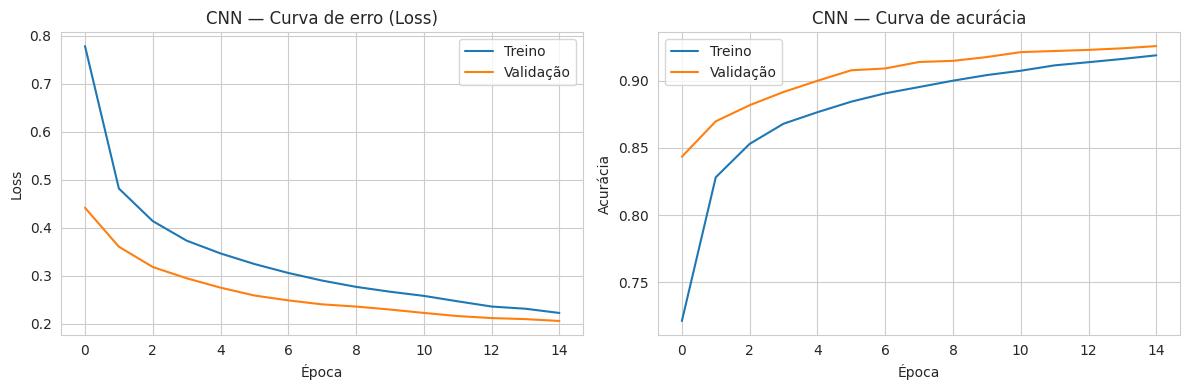

In [ ]:
plot_history(history_cnn, 'CNN')


### Análise das curvas de treinamento

Observa-se que a função de perda (loss) diminui continuamente tanto no conjunto de treino quanto no de validação, indicando aprendizado consistente ao longo das épocas. As curvas permanecem próximas durante todo o treinamento, sem aumento da perda de validação, o que sugere boa capacidade de generalização e ausência de sobreajuste.

Em relação à acurácia, ambas as curvas apresentam crescimento gradual até aproximadamente **92%** no treinamento e **93%** na validação. A pequena diferença entre elas é esperada devido ao uso de **Dropout**, que atua apenas durante o treinamento, tornando-o mais desafiador e podendo resultar em desempenho ligeiramente inferior ao observado na validação.

De forma geral, o comportamento das curvas demonstra um treinamento estável e uma boa capacidade de generalização da CNN para o problema de classificação do Fashion MNIST.

>>> CNN — Acurácia final no conjunto de teste: 0.9114 (loss=0.2405)


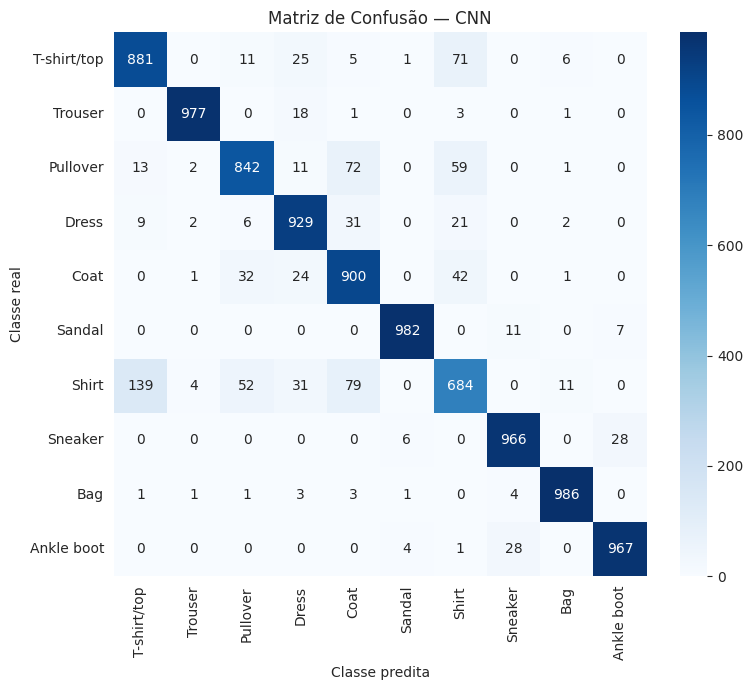

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.88      0.86      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.89      0.84      0.87      1000
       Dress       0.89      0.93      0.91      1000
        Coat       0.82      0.90      0.86      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.78      0.68      0.73      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [ ]:
acc_cnn, y_pred_cnn = evaluate_model(cnn, x_test_cnn, y_test, class_names, 'CNN')


### Análise da matriz de confusão

A matriz de confusão evidencia que a CNN apresentou elevado desempenho na classificação das imagens, com a maioria das predições concentradas na diagonal principal. Classes como **Trouser (977)**, **Dress (929)**, **Coat (900)**, **Sandal (982)**, **Sneaker (966)**, **Bag (986)** e **Ankle boot (967)** obtiveram altas taxas de acerto, demonstrando que a rede convolucional conseguiu extrair características discriminativas dessas categorias.

As principais confusões ocorreram entre peças de vestuário visualmente semelhantes. A classe **Shirt** permaneceu a mais difícil de classificar, sendo frequentemente confundida com **T-shirt/top (139)**, **Coat (79)** e **Pullover (52)**. Também foram observadas confusões entre **Pullover**, **Coat** e **Shirt**, indicando que essas categorias compartilham características visuais semelhantes, como formato e textura.

Em comparação com a MLP, a CNN apresentou melhor desempenho na maioria das classes, aumentando o número de classificações corretas para categorias como **T-shirt/top**, **Pullover**, **Dress**, **Coat**, **Sandal**, **Bag** e **Ankle boot**. Esses resultados confirmam a maior capacidade das redes convolucionais em capturar padrões espaciais das imagens, resultando em melhor desempenho na tarefa de classificação do Fashion MNIST.

# Questão 4 Comparação final entre MLP e CNN

Acurácia final no teste — MLP: 0.8759
Acurácia final no teste — CNN: 0.9114


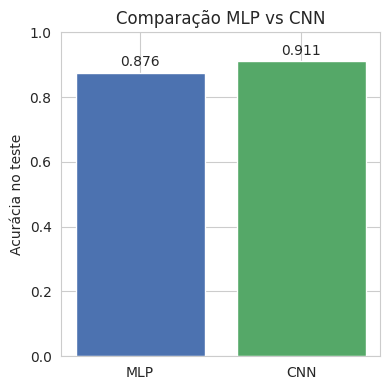

In [ ]:
print(f"Acurácia final no teste — MLP: {acc_mlp:.4f}")
print(f"Acurácia final no teste — CNN: {acc_cnn:.4f}")

plt.figure(figsize=(4, 4))
plt.bar(['MLP', 'CNN'], [acc_mlp, acc_cnn], color=['#4C72B0', '#55A868'])
plt.ylim(0, 1)
plt.ylabel('Acurácia no teste')
plt.title('Comparação MLP vs CNN')
for i, v in enumerate([acc_mlp, acc_cnn]):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()


**Discussão esperada:** de modo geral a CNN tende a superar o MLP no
Fashion-MNIST, pois as camadas convolucionais exploram a estrutura espacial
2D das imagens (bordas, texturas, formas locais) através de filtros
compartilhados, enquanto o MLP trata cada pixel como uma variável
independente após o *flatten*, perdendo a noção de vizinhança espacial.


## a) Visualização dos filtros da primeira camada convolucional

Extraímos os pesos (kernels) da camada `conv1` da CNN treinada na Seção 3 e
visualizamos cada um dos 32 filtros 3x3 aprendidos.


In [ ]:
# Pesos da primeira camada convolucional
filters, biases = cnn.get_layer("conv1").get_weights()

print(filters.shape)
# (3, 3, 1, 32)

(3, 3, 1, 32)


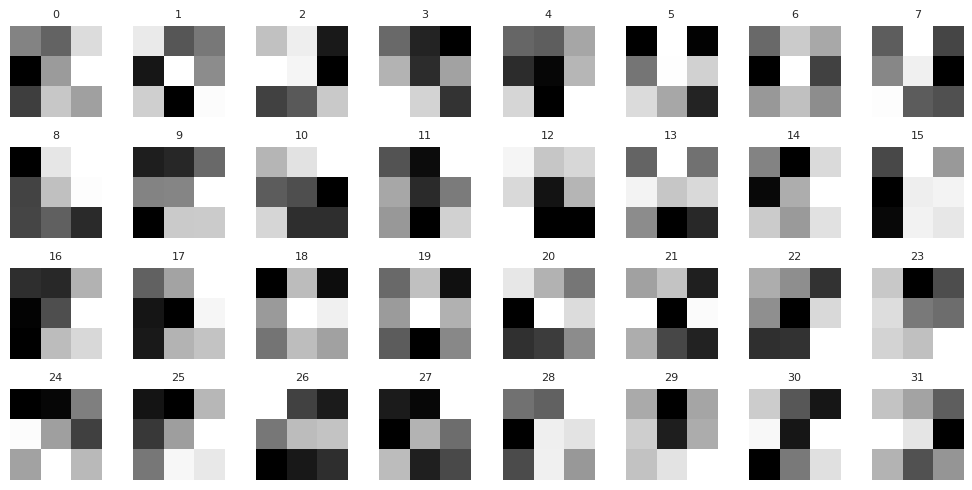

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    f = filters[:, :, 0, i]

    # Normalização apenas para visualização
    f = (f - f.min()) / (f.max() - f.min())

    ax.imshow(f, cmap="gray")
    ax.axis("off")
    ax.set_title(f"{i}", fontsize=8)

plt.tight_layout()
plt.show()

### Análise dos filtros da primeira camada convolucional

A visualização dos 32 filtros aprendidos pela primeira camada convolucional evidencia que a CNN aprendeu principalmente detectores de padrões básicos, como bordas horizontais, verticais e diagonais. Esses filtros possuem valores alternando entre regiões claras e escuras, o que indica sensibilidade a mudanças bruscas de intensidade na imagem.

Também é possível observar alguns filtros que atuam como detectores de contraste local, respondendo a transições entre fundo e objeto. Outros apresentam padrões mais difusos, que podem estar associados à detecção de texturas simples ou regiões específicas das peças de roupa.

De forma geral, os filtros da primeira camada não representam características complexas dos objetos, mas sim elementos primitivos da imagem. Essas informações são posteriormente combinadas pelas camadas seguintes da rede para formar representações mais abstratas, como contornos de roupas, formas de mangas, calçados e acessórios.

## b) Mapas de ativação de uma camada convolucional intermediária

Selecionamos 5 imagens do conjunto de teste e visualizamos os mapas de
ativação produzidos pela camada `conv2` (camada intermediária) da CNN.


In [ ]:
layer_outputs = [cnn.get_layer('conv1').output, cnn.get_layer('conv2').output]
activation_model = models.Model(inputs=cnn.inputs[0], outputs=layer_outputs)

# Seleciona 5 imagens aleatórias do conjunto de teste
np.random.seed(SEED)
sample_indices = np.random.choice(len(x_test_cnn), 5, replace=False)
sample_images = x_test_cnn[sample_indices]
sample_labels = y_test[sample_indices]

conv1_acts, conv2_acts = activation_model.predict(sample_images, verbose=0)
print("Formato das ativações da conv2:", conv2_acts.shape)  # (5, 14, 14, 64)


Formato das ativações da conv2: (5, 14, 14, 64)


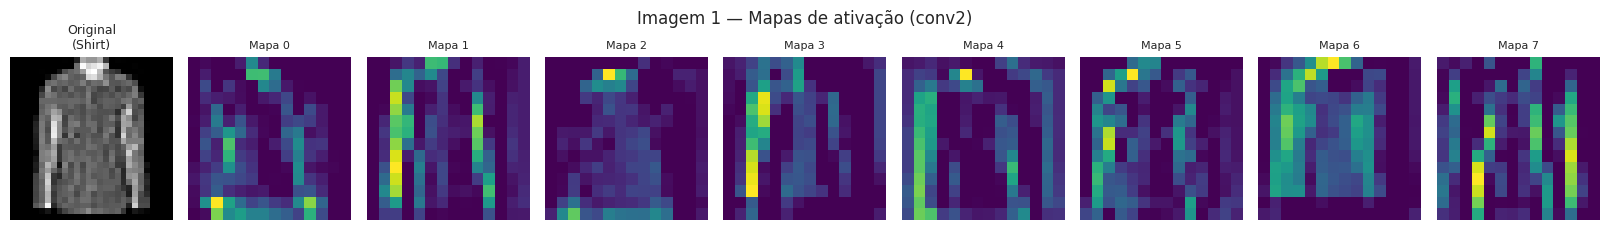

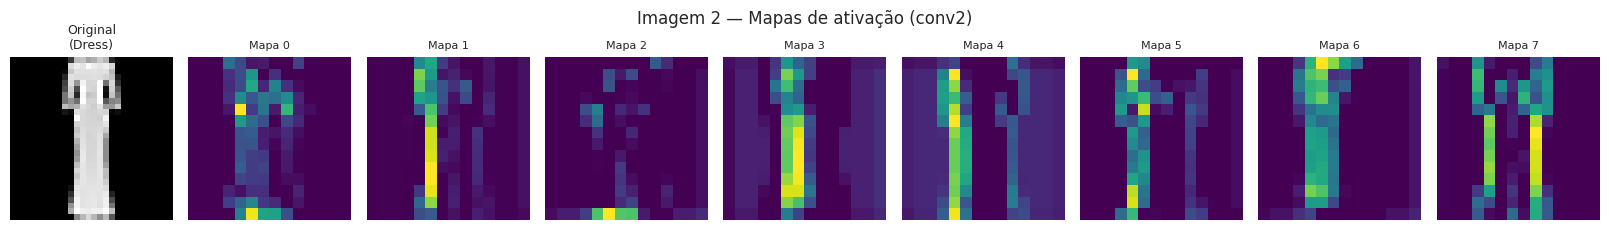

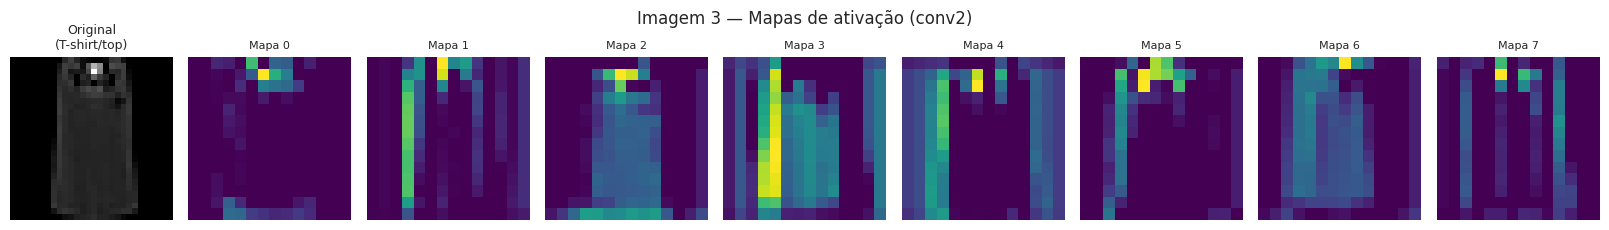

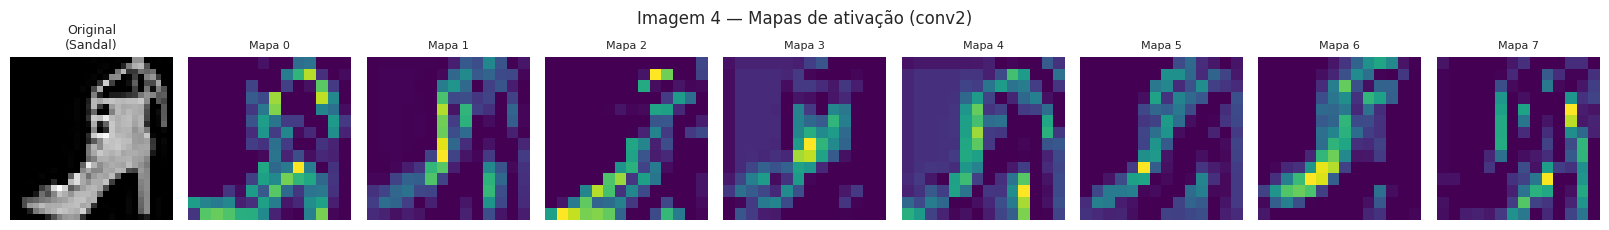

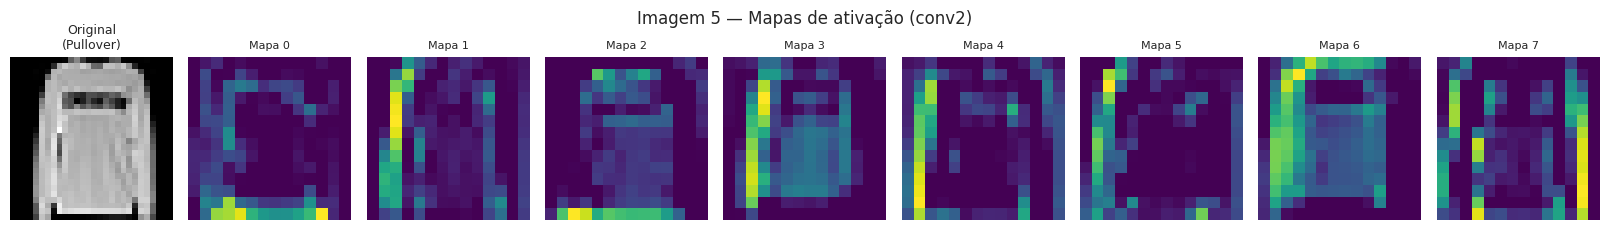

In [ ]:
N_MAPS = 8  # quantidade de mapas de ativação exibidos por imagem

for idx in range(len(sample_indices)):
    img = sample_images[idx].reshape(28, 28)
    act = conv2_acts[idx]  # (H, W, n_filtros)

    fig, axes = plt.subplots(1, N_MAPS + 1, figsize=((N_MAPS + 1) * 1.8, 2.3))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Original\n({class_names[sample_labels[idx]]})', fontsize=9)
    axes[0].axis('off')

    for m in range(N_MAPS):
        axes[m + 1].imshow(act[:, :, m], cmap='viridis')
        axes[m + 1].set_title(f'Mapa {m}', fontsize=8)
        axes[m + 1].axis('off')

    plt.suptitle(f'Imagem {idx + 1} — Mapas de ativação (conv2)')
    plt.tight_layout()
    plt.show()


### Análise dos mapas de ativação (camada conv2)

A imagem mostra os mapas de ativação da segunda camada convolucional para uma entrada da classe **Pullover**. Observa-se que diferentes filtros respondem a regiões específicas da peça, evidenciando que a rede já está capturando padrões mais complexos do que simples bordas.

Alguns mapas destacam fortemente os **contornos laterais e superiores da roupa**, especialmente a região da gola e das mangas, indicando que certos filtros estão especializados em bordas verticais e transições de intensidade mais marcadas. Outros mapas apresentam respostas mais distribuídas, ativando regiões internas do objeto, o que sugere sensibilidade a texturas e áreas homogêneas da peça.

Também é possível notar que nem todos os filtros são igualmente ativados: alguns apresentam respostas fracas ou quase nulas, o que indica que nem todos os detectores são relevantes para essa amostra específica. Isso é esperado, já que cada filtro aprende a identificar padrões diferentes ao longo do treinamento.

De forma geral, os mapas evidenciam que a CNN está conseguindo isolar características importantes do **Pullover**, como formato global e contornos principais, o que contribui para a boa capacidade de discriminação entre classes semelhantes (como Coat e Shirt).

## c) Selecione exemplos corretamente classificados e exemplos classificados incorretamente

In [ ]:
pred = cnn.predict(x_test_cnn)
pred_class = np.argmax(pred, axis=1)
prob = np.max(pred, axis=1)

correct = np.where(pred_class == y_test)[0]
correct[:10]

wrong = np.where(pred_class != y_test)[0]
wrong[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


array([17, 23, 25, 40, 42, 49, 57, 66, 67, 68])

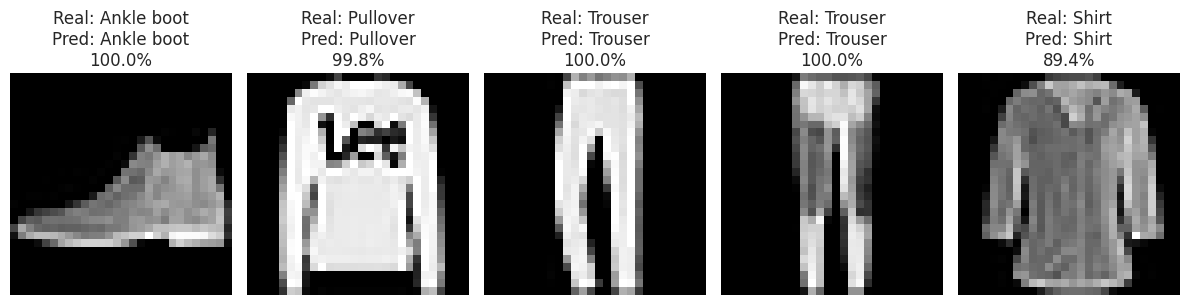

In [ ]:
plt.figure(figsize=(12,6))
for i in range(5):
    idx = correct[i]
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(
        f"Real: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[pred_class[idx]]}\n"
        f"{prob[idx]*100:.1f}%"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

### Análise dos exemplos de classificação da CNN

Os exemplos apresentados mostram o desempenho da CNN em diferentes classes do Fashion MNIST, com predominância de predições corretas e alta confiança associada às previsões.

Nos casos de **Ankle boot**, **Pullover** e **Trouser**, o modelo apresenta acertos com probabilidades extremamente altas (≈99% a 100%), indicando que essas classes possuem características visuais bem definidas e facilmente separáveis pelo modelo. Isso reforça a capacidade da CNN em capturar padrões espaciais relevantes como formato geral, contornos e estrutura dos objetos.

No último exemplo, da classe **Shirt**, observa-se uma predição correta, porém com menor confiança (**89,4%**). Esse comportamento é esperado, pois camisetas e camisas possuem maior variabilidade visual e alta similaridade com outras classes de roupas superiores, como *T-shirt/top*, *Pullover* e *Coat*, tornando a decisão mais difícil para o modelo.

De forma geral, os resultados indicam que a CNN não apenas apresenta alta taxa de acerto, mas também atribui probabilidades coerentes com o grau de dificuldade de cada amostra, demonstrando boa capacidade de generalização e calibração das previsões.

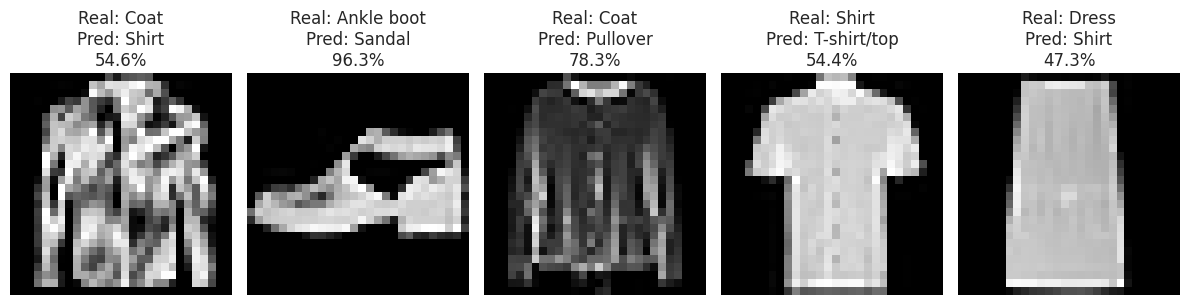

In [ ]:
plt.figure(figsize=(12,6))
for i in range(5):
    idx = wrong[i]
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(
        f"Real: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[pred_class[idx]]}\n"
        f"{prob[idx]*100:.1f}%"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

### Análise dos exemplos incorretamente classificados

Os exemplos apresentados mostram casos em que a CNN realizou predições incorretas, evidenciando os limites do modelo na separação de classes visualmente semelhantes.

No primeiro exemplo, uma peça da classe **Coat** foi classificada como **Shirt** com confiança de 54,6%, indicando uma forte sobreposição visual entre essas categorias, especialmente em relação ao formato geral e presença de mangas.

No segundo caso, um **Ankle boot** foi classificado como **Sandal** com alta confiança (96,3%). Apesar de ser um erro, esse resultado sugere que o modelo focou em características gerais do calçado, como formato e área do pé, mas falhou em capturar detalhes mais específicos, como fechamento e altura do cano.

No terceiro exemplo, um **Coat** foi confundido com **Pullover** (78,3%), reforçando a dificuldade da rede em distinguir peças de vestuário superiores que possuem silhuetas e texturas muito semelhantes.

No quarto caso, uma **Shirt** foi classificada como **T-shirt/top** com 54,4% de confiança, indicando ambiguidade entre categorias que diferem apenas em detalhes sutis como gola e corte.

Por fim, uma **Dress** foi classificada como **Shirt** com 47,3%, demonstrando baixa confiança e forte incerteza do modelo, o que é típico em regiões de decisão próximas entre classes com grande similaridade visual.

De forma geral, os erros concentram-se em classes de vestuário superior, onde há maior sobreposição de características visuais. Além disso, alguns erros com alta confiança indicam que, mesmo com uma boa taxa de acerto global, a CNN ainda pode ser enganada por padrões visuais muito semelhantes entre diferentes categorias.

# Questão 5 — Autoencoders com Fashion-MNIST

Esta seção utiliza novamente a base **Fashion-MNIST** (já carregada e
pré-processada na Seção 1 deste notebook) para dois experimentos com
autoencoders convolucionais:

- **5a)** treinamento de um autoencoder para reconstrução de imagens,
  comparando três tamanhos diferentes de espaço latente;
- **5b)** treinamento de um autoencoder de remoção de ruído (*denoising
  autoencoder*), utilizando a mesma arquitetura de base.

**Observação sobre o volume de dados:** para permitir iteração rápida
durante o desenvolvimento, os autoencoders desta seção foram treinados
com uma subamostra estratificada de 15.000 imagens de treino e 3.000 de
validação (a partir de `x_train_cnn`/`x_val_cnn` já existentes). O
conjunto de teste utilizado para avaliação e visualização permanece
completo (10.000 imagens). Caso deseje treinar com a base completa
(54.000 imagens), basta remover a etapa de subamostragem indicada abaixo
e reutilizar diretamente `x_train_cnn`/`x_val_cnn`; os resultados tendem
a melhorar ainda mais, ao custo de um tempo de treinamento maior.

## a) Autoencoder para reconstrução de imagens

### Arquitetura utilizada

| Bloco | Camada | Saída | Ativação |
|---|---|---|---|
| Entrada | Input | 28x28x1 | - |
| Encoder | Conv2D(32, 3x3) + MaxPooling2D | 14x14x32 | ReLU |
| Encoder | Conv2D(64, 3x3) + MaxPooling2D | 7x7x64 | ReLU |
| Encoder | Flatten + Dense(latent_dim) | latent_dim | ReLU |
| Decoder | Dense(7\*7\*64) + Reshape | 7x7x64 | ReLU |
| Decoder | Conv2DTranspose(64, 3x3, stride 2) | 14x14x64 | ReLU |
| Decoder | Conv2DTranspose(32, 3x3, stride 2) | 28x28x32 | ReLU |
| Saída | Conv2D(1, 3x3) | 28x28x1 | Sigmoid |

Otimizador: Adam (lr=1e-3) · Função de perda: MSE

Foram treinadas **três versões** do modelo, variando apenas o tamanho do
espaço latente: **8, 32 e 128** neurônios.

### Justificativa da arquitetura

A arquitetura segue o mesmo padrão da CNN utilizada nas Questões 3 e 4,
com camadas convolucionais no *encoder* para extrair características
espaciais e reduzir a dimensionalidade via *pooling*. O gargalo (*bottleneck*)
é uma camada densa cujo tamanho (`latent_dim`) controla quanta informação
da imagem original pode ser preservada: quanto menor o espaço latente,
maior a compressão e, em geral, maior a perda de detalhes na
reconstrução. O *decoder* espelha o *encoder*, utilizando
`Conv2DTranspose` para reverter o *downsampling* até recuperar a
resolução original (28x28). A ativação **sigmoid** na camada de saída é
adequada pois os pixels de entrada estão normalizados no intervalo
[0, 1].

In [ ]:
def build_autoencoder(latent_dim, name='AE'):
    """Autoencoder convolucional com gargalo denso de tamanho latent_dim."""
    inputs = layers.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)          # 14x14x32
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)          # 7x7x64
    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)

    # Decoder
    x = layers.Dense(7 * 7 * 64, activation='relu')(latent)
    x = layers.Reshape((7, 7, 64))(x)
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)  # 14x14x64
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)  # 28x28x32
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)              # 28x28x1

    return models.Model(inputs, outputs, name=name)

# Exemplo de arquitetura (latent_dim=32)
build_autoencoder(32, name='AE_exemplo').summary()


Model: "AE_exemplo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │       100,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3136)           │       103,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,369 (1.06 MB)

 Trainable params: 278,369 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Subamostragem estratificada para viabilizar o treino de 3 modelos em tempo hábil
x_train_ae, _, y_train_ae, _ = train_test_split(
    x_train_cnn, y_train, train_size=15000, random_state=SEED, stratify=y_train
)
x_val_ae, _, y_val_ae, _ = train_test_split(
    x_val_cnn, y_val, train_size=3000, random_state=SEED, stratify=y_val
)

print("Treino (AE):", x_train_ae.shape, " Validação (AE):", x_val_ae.shape)

latent_dims = [8, 32, 128]
histories_a = {}
autoencoders = {}

for ld in latent_dims:
    tf.random.set_seed(SEED)
    ae = build_autoencoder(ld, name=f'AE_latent{ld}')
    ae.compile(optimizer=Adam(1e-3), loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    hist = ae.fit(
        x_train_ae, x_train_ae,
        validation_data=(x_val_ae, x_val_ae),
        epochs=8, batch_size=256,
        callbacks=[early_stop], verbose=2
    )
    histories_a[ld] = hist.history
    autoencoders[ld] = ae
    print(f'>>> latent_dim={ld} — melhor val_loss (MSE): {min(hist.history["val_loss"]):.5f}\n')


Treino (AE): (15000, 28, 28, 1)  Validação (AE): (3000, 28, 28, 1)
Epoch 1/8
59/59 - 40s - 682ms/step - loss: 0.1124 - val_loss: 0.0647
Epoch 2/8
59/59 - 39s - 661ms/step - loss: 0.0445 - val_loss: 0.0339
Epoch 3/8
59/59 - 41s - 698ms/step - loss: 0.0313 - val_loss: 0.0292
Epoch 4/8
59/59 - 40s - 671ms/step - loss: 0.0282 - val_loss: 0.0269
Epoch 5/8
59/59 - 39s - 668ms/step - loss: 0.0264 - val_loss: 0.0254
Epoch 6/8
59/59 - 41s - 698ms/step - loss: 0.0251 - val_loss: 0.0243
Epoch 7/8
59/59 - 40s - 686ms/step - loss: 0.0241 - val_loss: 0.0235
Epoch 8/8
59/59 - 45s - 762ms/step - loss: 0.0234 - val_loss: 0.0229
>>> latent_dim=8 — melhor val_loss (MSE): 0.02286

Epoch 1/8
59/59 - 52s - 878ms/step - loss: 0.0947 - val_loss: 0.0461
Epoch 2/8
59/59 - 78s - 1s/step - loss: 0.0334 - val_loss: 0.0264
Epoch 3/8
59/59 - 44s - 753ms/step - loss: 0.0247 - val_loss: 0.0228
Epoch 4/8
59/59 - 83s - 1s/step - loss: 0.0218 - val_loss: 0.0204
Epoch 5/8
59/59 - 44s - 742ms/step - loss: 0.0196 - val_loss

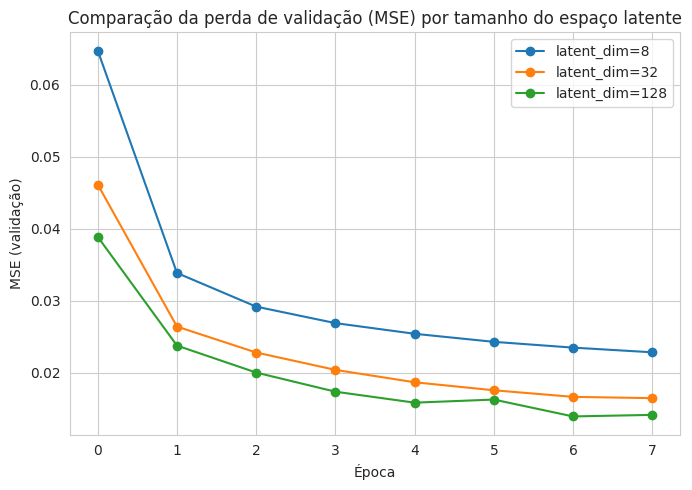

In [ ]:
plt.figure(figsize=(7, 5))
for ld in latent_dims:
    plt.plot(histories_a[ld]['val_loss'], marker='o', label=f'latent_dim={ld}')
plt.title('Comparação da perda de validação (MSE) por tamanho do espaço latente')
plt.xlabel('Época')
plt.ylabel('MSE (validação)')
plt.legend()
plt.tight_layout()
plt.show()


### Análise das curvas de treinamento

As três versões do autoencoder apresentam comportamento de convergência
semelhante: queda acentuada do erro (MSE) nas primeiras épocas seguida
de estabilização gradual, sem sinais de sobreajuste (as curvas de
validação acompanham de perto as de treino em todas as configurações).

O tamanho do espaço latente tem impacto direto na qualidade final da
reconstrução: quanto maior o gargalo, menor o erro de validação obtido.
Com **latent_dim=8** o modelo converge para um MSE de validação de
aproximadamente **0,0229**, com **latent_dim=32** o erro cai para
**0,0165**, e com **latent_dim=128** chega a **0,0140** — uma redução de
cerca de **39%** em relação ao modelo mais comprimido. Isso é esperado,
pois um espaço latente maior permite reter mais informação sobre a
imagem original, ao custo de uma representação menos compacta.

In [ ]:
# Seleciona 10 imagens do conjunto de teste
np.random.seed(SEED)
sample_indices = np.random.choice(len(x_test_cnn), 10, replace=False)
sample_images = x_test_cnn[sample_indices]
sample_labels = y_test[sample_indices]

reconstructions_a = {}
mse_a = {}
for ld in latent_dims:
    recon = autoencoders[ld].predict(sample_images, verbose=0)
    reconstructions_a[ld] = recon
    mse_a[ld] = np.mean((recon - sample_images) ** 2, axis=(1, 2, 3))

print("Índice | Classe        | MSE(latent=8) | MSE(latent=32) | MSE(latent=128)")
for i in range(10):
    print(f"{sample_indices[i]:6d} | {class_names[sample_labels[i]]:13s} | "
          f"{mse_a[8][i]:.5f}      | {mse_a[32][i]:.5f}       | {mse_a[128][i]:.5f}")

print("\nMSE médio no lote de 10 imagens:")
for ld in latent_dims:
    print(f"  latent_dim={ld}: {mse_a[ld].mean():.5f}")


Índice | Classe        | MSE(latent=8) | MSE(latent=32) | MSE(latent=128)
  6252 | Shirt         | 0.01287      | 0.01043       | 0.00848
  4684 | Dress         | 0.02437      | 0.01185       | 0.00991
  1731 | T-shirt/top   | 0.00406      | 0.00365       | 0.00324
  4742 | Sandal        | 0.04073      | 0.03224       | 0.02700
  4521 | Pullover      | 0.01966      | 0.01297       | 0.01196
  6340 | Sandal        | 0.02083      | 0.01352       | 0.01076
   576 | Ankle boot    | 0.05091      | 0.02522       | 0.02037
  5202 | Sandal        | 0.07360      | 0.03668       | 0.03171
  6363 | Shirt         | 0.01454      | 0.01248       | 0.01027
   439 | Dress         | 0.01856      | 0.01128       | 0.00890

MSE médio no lote de 10 imagens:
  latent_dim=8: 0.02801
  latent_dim=32: 0.01703
  latent_dim=128: 0.01426


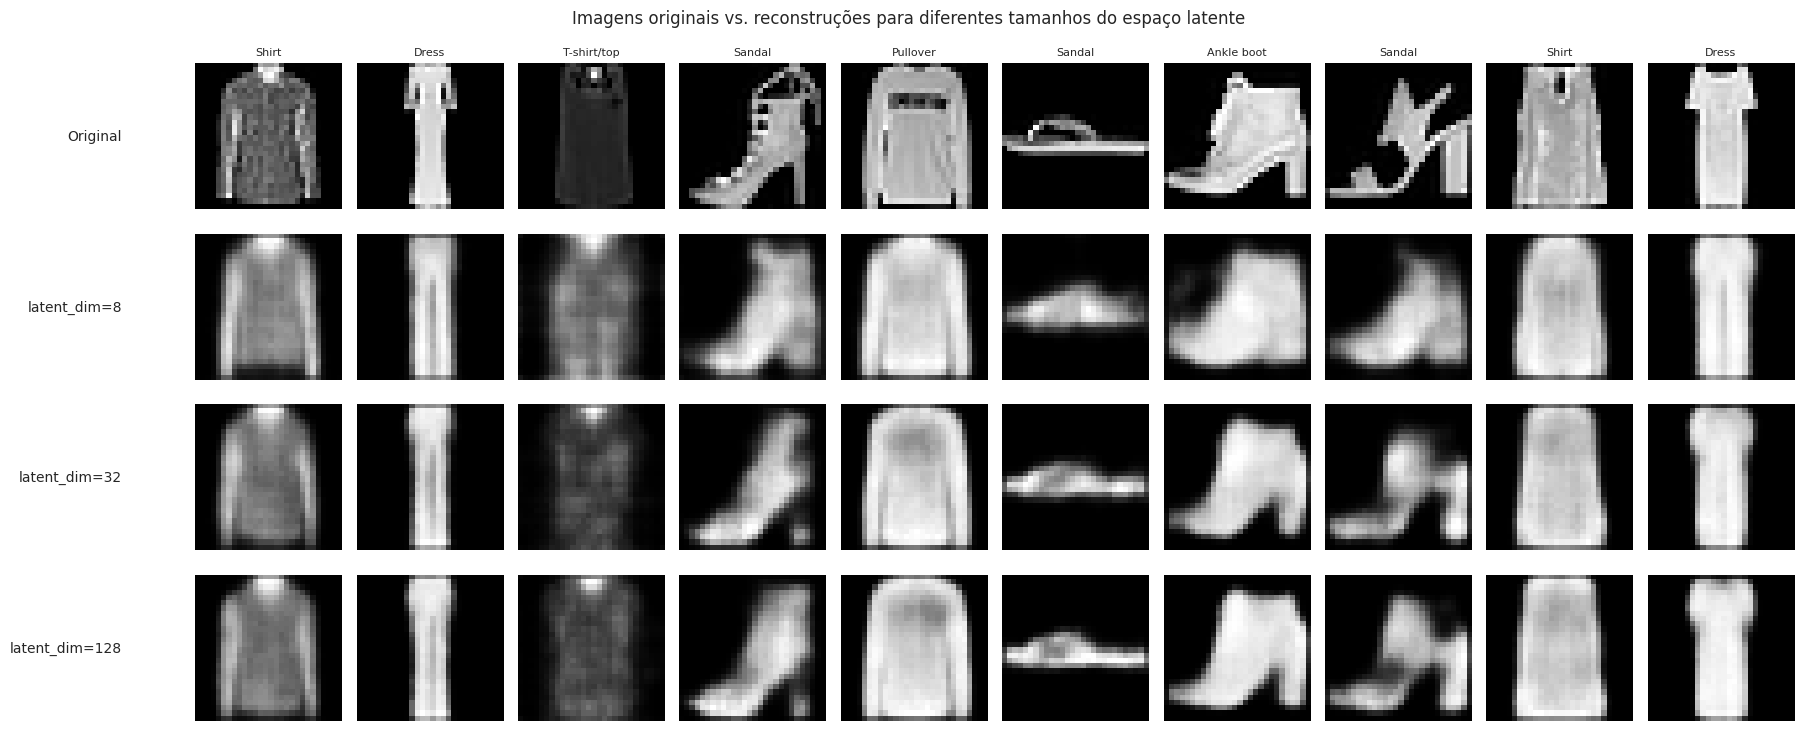

In [ ]:
fig, axes = plt.subplots(4, 10, figsize=(18, 7.5))
row_titles = ['Original', 'latent_dim=8', 'latent_dim=32', 'latent_dim=128']

for j in range(10):
    axes[0, j].imshow(sample_images[j].reshape(28, 28), cmap='gray')
    axes[0, j].set_title(class_names[sample_labels[j]], fontsize=8)
    axes[0, j].axis('off')

for row_i, ld in enumerate(latent_dims, start=1):
    for j in range(10):
        axes[row_i, j].imshow(reconstructions_a[ld][j].reshape(28, 28), cmap='gray')
        axes[row_i, j].axis('off')

for row_i, title in enumerate(row_titles):
    axes[row_i, 0].text(-0.5, 0.5, title, transform=axes[row_i, 0].transAxes,
                         fontsize=10, va='center', ha='right')

plt.suptitle('Imagens originais vs. reconstruções para diferentes tamanhos do espaço latente')
plt.tight_layout()
plt.show()


### Análise qualitativa das reconstruções

A inspeção visual confirma o que os valores de MSE indicam: com
**latent_dim=8** as reconstruções capturam apenas o formato geral da
peça de roupa, perdendo detalhes finos (texturas, estampas, contornos
mais complexos) — por exemplo, as sandálias reconstruídas ficam bastante
borradas e o contorno da bota (Ankle boot) perde definição. Com
**latent_dim=32** os contornos ficam mais nítidos e alguns detalhes
internos começam a aparecer, representando um bom equilíbrio entre
compressão e qualidade. Com **latent_dim=128** as reconstruções são
visualmente as mais próximas das imagens originais, com bordas mais
definidas e menor perda de detalhes, o que é coerente com o menor MSE
observado nessa configuração.

De forma geral, quanto maior o espaço latente, melhor a qualidade da
reconstrução — como esperado, já que menos informação é descartada no
gargalo do autoencoder. A escolha do tamanho ideal do espaço latente,
na prática, depende do compromisso desejado entre compressão
(dimensionalidade da representação) e fidelidade da reconstrução.

## b) Autoencoder de remoção de ruído (Denoising Autoencoder)

Nesta etapa, adicionamos ruído gaussiano aleatório às imagens de entrada
e treinamos um novo autoencoder cujo objetivo é reconstruir a imagem
**limpa** (sem ruído) a partir da versão ruidosa. A arquitetura utilizada
é a mesma `build_autoencoder`, com **latent_dim=32** — o valor que, na
etapa anterior, apresentou um bom equilíbrio entre qualidade de
reconstrução e tamanho do espaço latente.

Ruído adicionado. Formatos: (15000, 28, 28, 1) (3000, 28, 28, 1) (10000, 28, 28, 1)


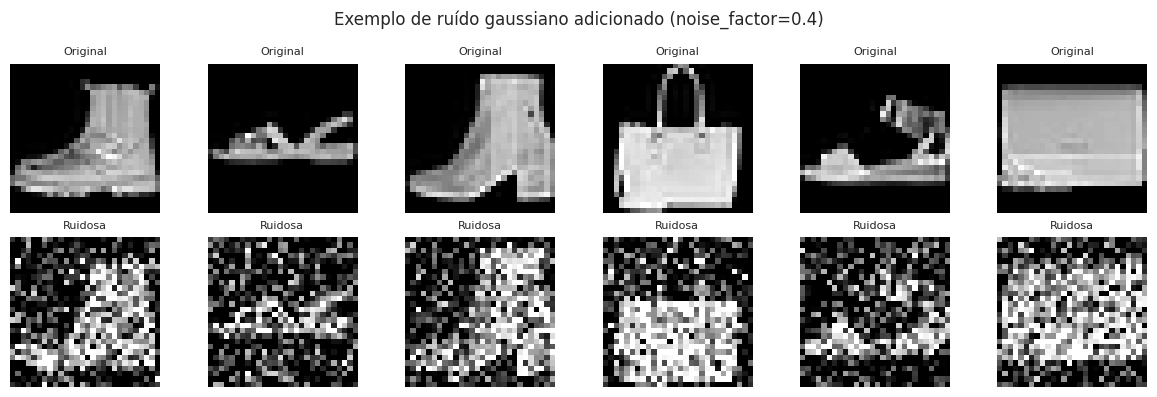

In [ ]:
NOISE_FACTOR = 0.4

def add_noise(x, noise_factor=NOISE_FACTOR, seed=None):
    """Adiciona ruído gaussiano às imagens e recorta os valores para [0, 1]."""
    rng = np.random.RandomState(seed)
    noisy = x + noise_factor * rng.normal(loc=0.0, scale=1.0, size=x.shape)
    return np.clip(noisy, 0.0, 1.0).astype('float32')

x_train_noisy = add_noise(x_train_ae, seed=SEED)
x_val_noisy   = add_noise(x_val_ae, seed=SEED + 1)
x_test_noisy  = add_noise(x_test_cnn, seed=SEED + 2)

print("Ruído adicionado. Formatos:", x_train_noisy.shape, x_val_noisy.shape, x_test_noisy.shape)

# Visualização rápida: original vs. ruidosa
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for j in range(6):
    axes[0, j].imshow(x_train_ae[j].reshape(28, 28), cmap='gray')
    axes[0, j].set_title('Original', fontsize=8)
    axes[0, j].axis('off')
    axes[1, j].imshow(x_train_noisy[j].reshape(28, 28), cmap='gray')
    axes[1, j].set_title('Ruidosa', fontsize=8)
    axes[1, j].axis('off')
plt.suptitle(f'Exemplo de ruído gaussiano adicionado (noise_factor={NOISE_FACTOR})')
plt.tight_layout()
plt.show()


### Justificativa da configuração de treinamento

O ruído foi gerado a partir de uma distribuição normal (média 0,
desvio-padrão igual a 1) escalada por um fator `noise_factor=0.4`, e os
valores resultantes foram recortados para o intervalo [0, 1] para manter
a mesma faixa de valores das imagens originais. O modelo é treinado para
mapear **imagem ruidosa → imagem limpa** (e não ruidosa → ruidosa), o
que força o autoencoder a aprender uma representação latente que captura
a estrutura relevante da peça de roupa e descarta o ruído aleatório, já
que este não carrega informação útil para a reconstrução.

In [ ]:
tf.random.set_seed(SEED)
denoiser = build_autoencoder(32, name='Denoising_AE')
denoiser.compile(optimizer=Adam(1e-3), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_denoise = denoiser.fit(
    x_train_noisy, x_train_ae,
    validation_data=(x_val_noisy, x_val_ae),
    epochs=10, batch_size=256,
    callbacks=[early_stop], verbose=2
)

print("Melhor val_loss (denoising):", min(history_denoise.history['val_loss']))


Epoch 1/10
59/59 - 41s - 693ms/step - loss: 0.1031 - val_loss: 0.0798
Epoch 2/10
59/59 - 39s - 664ms/step - loss: 0.0571 - val_loss: 0.0357
Epoch 3/10
59/59 - 41s - 700ms/step - loss: 0.0302 - val_loss: 0.0271
Epoch 4/10
59/59 - 40s - 676ms/step - loss: 0.0258 - val_loss: 0.0246
Epoch 5/10
59/59 - 41s - 691ms/step - loss: 0.0237 - val_loss: 0.0232
Epoch 6/10
59/59 - 42s - 706ms/step - loss: 0.0223 - val_loss: 0.0220
Epoch 7/10
59/59 - 39s - 665ms/step - loss: 0.0213 - val_loss: 0.0212
Epoch 8/10
59/59 - 39s - 663ms/step - loss: 0.0205 - val_loss: 0.0205
Epoch 9/10
59/59 - 41s - 690ms/step - loss: 0.0198 - val_loss: 0.0199
Epoch 10/10
59/59 - 41s - 700ms/step - loss: 0.0193 - val_loss: 0.0194
Melhor val_loss (denoising): 0.0194427277892828


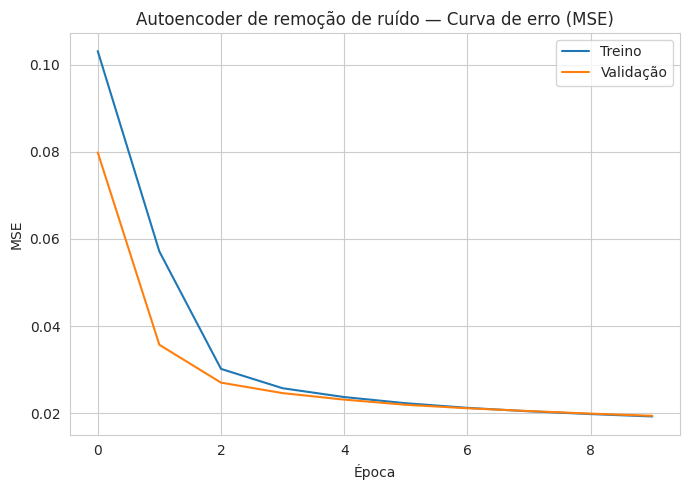

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history_denoise.history['loss'], label='Treino')
plt.plot(history_denoise.history['val_loss'], label='Validação')
plt.title('Autoencoder de remoção de ruído — Curva de erro (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()


### Análise das curvas de treinamento

A curva de erro cai rapidamente nas primeiras épocas (de 0,103 para
0,036 já na segunda época) e converge de forma estável, atingindo um MSE
de validação de aproximadamente **0,0194** ao final do treinamento. As
curvas de treino e validação permanecem muito próximas, sem indícios de
sobreajuste — resultado esperado, já que o ruído aplicado a cada época é
sempre diferente daquele visto anteriormente em termos de realização
aleatória, funcionando como uma forma de regularização/aumento de
dados.

In [ ]:
sample_noisy = x_test_noisy[sample_indices]
denoised = denoiser.predict(sample_noisy, verbose=0)

mse_noisy = np.mean((sample_noisy - sample_images) ** 2, axis=(1, 2, 3))
mse_denoised = np.mean((denoised - sample_images) ** 2, axis=(1, 2, 3))

print("Índice | Classe        | MSE(ruidosa vs original) | MSE(denoised vs original)")
for i in range(10):
    print(f"{sample_indices[i]:6d} | {class_names[sample_labels[i]]:13s} | "
          f"{mse_noisy[i]:.5f}                 | {mse_denoised[i]:.5f}")

print("\nMSE médio (ruidosa vs original):  ", round(mse_noisy.mean(), 5))
print("MSE médio (denoised vs original):", round(mse_denoised.mean(), 5))


Índice | Classe        | MSE(ruidosa vs original) | MSE(denoised vs original)
  6252 | Shirt         | 0.09355                 | 0.01396
  4684 | Dress         | 0.08514                 | 0.01612
  1731 | T-shirt/top   | 0.07713                 | 0.00507
  4742 | Sandal        | 0.08975                 | 0.03540
  4521 | Pullover      | 0.08865                 | 0.01475
  6340 | Sandal        | 0.07984                 | 0.01714
   576 | Ankle boot    | 0.07531                 | 0.02293
  5202 | Sandal        | 0.07852                 | 0.04128
  6363 | Shirt         | 0.08874                 | 0.01434
   439 | Dress         | 0.08012                 | 0.01517

MSE médio (ruidosa vs original):   0.08368
MSE médio (denoised vs original): 0.01962


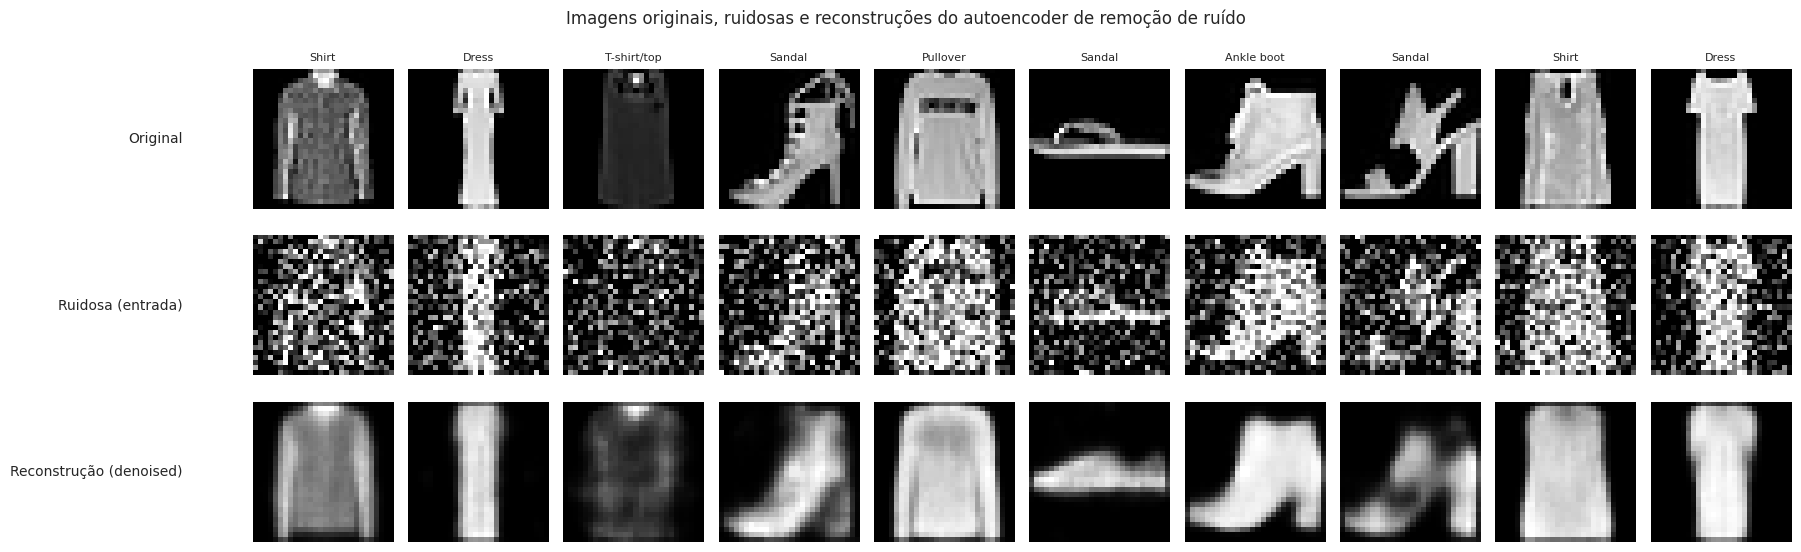

In [ ]:
fig, axes = plt.subplots(3, 10, figsize=(18, 5.7))
row_titles = ['Original', 'Ruidosa (entrada)', 'Reconstrução (denoised)']

for j in range(10):
    axes[0, j].imshow(sample_images[j].reshape(28, 28), cmap='gray')
    axes[0, j].set_title(class_names[sample_labels[j]], fontsize=8)
    axes[0, j].axis('off')

    axes[1, j].imshow(sample_noisy[j].reshape(28, 28), cmap='gray')
    axes[1, j].axis('off')

    axes[2, j].imshow(denoised[j].reshape(28, 28), cmap='gray')
    axes[2, j].axis('off')

for row_i, title in enumerate(row_titles):
    axes[row_i, 0].text(-0.5, 0.5, title, transform=axes[row_i, 0].transAxes,
                         fontsize=10, va='center', ha='right')

plt.suptitle('Imagens originais, ruidosas e reconstruções do autoencoder de remoção de ruído')
plt.tight_layout()
plt.show()


### Análise qualitativa e conclusão

A comparação quantitativa mostra uma redução expressiva do erro de
reconstrução: o MSE médio entre a imagem ruidosa e a original é de
**0,0837**, enquanto o MSE médio entre a reconstrução do denoising
autoencoder e a imagem original cai para **0,0196** — uma redução de
aproximadamente **76,6%**. Isso confirma que o modelo aprendeu a
remover, de forma eficaz, o ruído gaussiano introduzido artificialmente.

Visualmente, as imagens de entrada ruidosas ficam quase irreconhecíveis
em algumas classes, com o padrão granular do ruído sobrepondo o contorno
da peça de roupa. Ainda assim, as reconstruções produzidas pelo
denoising autoencoder recuperam de forma consistente o formato e os
principais detalhes das peças (por exemplo, o cano da bota, a alça da
sandália e o formato do vestido), embora com alguma suavização em
relação às imagens originais — efeito esperado, já que o gargalo do
autoencoder (latent_dim=32) impõe uma perda de informação semelhante à
observada na Questão 5a.

Em suma, o experimento demonstra que autoencoders convolucionais são
capazes não apenas de comprimir/reconstruir imagens, mas também de
aprender representações robustas a ruído, filtrando perturbações
aleatórias e preservando as características estruturais relevantes dos
dados.